# ─────────────────────────────────────────────────────────────
# PHASE 1 | Data Foundation
# ─────────────────────────────────────────────────────────────

# SECTION 1 | LOAD DATA & FEATURE ENGINEERING

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load Dataset
data = pd.read_excel("CPI_2014_2024.xlsx")

# Create Date feature
data['Date'] = pd.to_datetime(
    data['year'].astype(str) + '-' +
    data['month_code'].astype(str) + '-01'
)
data = data.sort_values('Date')

# Core features
data['CPI_value']      = data['cpi']
data['Inflation_rate'] = data['inflation']

# Group key for all lag/rolling operations
grp = ['state', 'sector', 'group', 'subgroup']

# Month-over-Month change
data['CPI_MoM_change'] = (
    data.groupby(grp)['CPI_value'].diff()
)

# Year-over-Year change
data['CPI_YoY_change'] = (
    data.groupby(grp)['CPI_value'].diff(12)
)

# 6-month rolling volatility
data['CPI_rolling_std_6m'] = (
    data.groupby(grp)['CPI_value']
    .rolling(window=6).std()
    .reset_index(level=[0,1,2,3], drop=True)
)

# Inflation shock flag — |inflation| > 6%
data['Inflation_shock'] = np.where(
    abs(data['Inflation_rate']) > 6, 1, 0
)

# Lag features
data['CPI_lag_1'] = data.groupby(grp)['CPI_value'].shift(1)
data['CPI_lag_3'] = data.groupby(grp)['CPI_value'].shift(3)
data['CPI_lag_6'] = data.groupby(grp)['CPI_value'].shift(6)

data_features = data.copy()
print("Feature Engineering Complete — Shape:", data_features.shape)
print("Columns:", list(data_features.columns))

Feature Engineering Complete — Shape: (274674, 21)
Columns: ['baseyear', 'year', 'month_code', 'month', 'state', 'sector', 'group', 'subgroup', 'cpi', 'inflation', 'status', 'Date', 'CPI_value', 'Inflation_rate', 'CPI_MoM_change', 'CPI_YoY_change', 'CPI_rolling_std_6m', 'Inflation_shock', 'CPI_lag_1', 'CPI_lag_3', 'CPI_lag_6']


# SECTION 2 | DATA INSPECTION

DATASET OVERVIEW
Shape          : (274674, 21)
Date Range     : 2014-01-01 00:00:00 → 2024-12-01 00:00:00
Duplicates     : 0

Data Types:
 baseyear                       int64
year                           int64
month_code                     int64
month                         object
state                         object
sector                        object
group                         object
subgroup                      object
cpi                          float64
inflation                    float64
status                        object
Date                  datetime64[ns]
CPI_value                    float64
Inflation_rate               float64
CPI_MoM_change               float64
CPI_YoY_change               float64
CPI_rolling_std_6m           float64
Inflation_shock                int64
CPI_lag_1                    float64
CPI_lag_3                    float64
CPI_lag_6                    float64
dtype: object

Missing Values:
 baseyear                  0
year                    

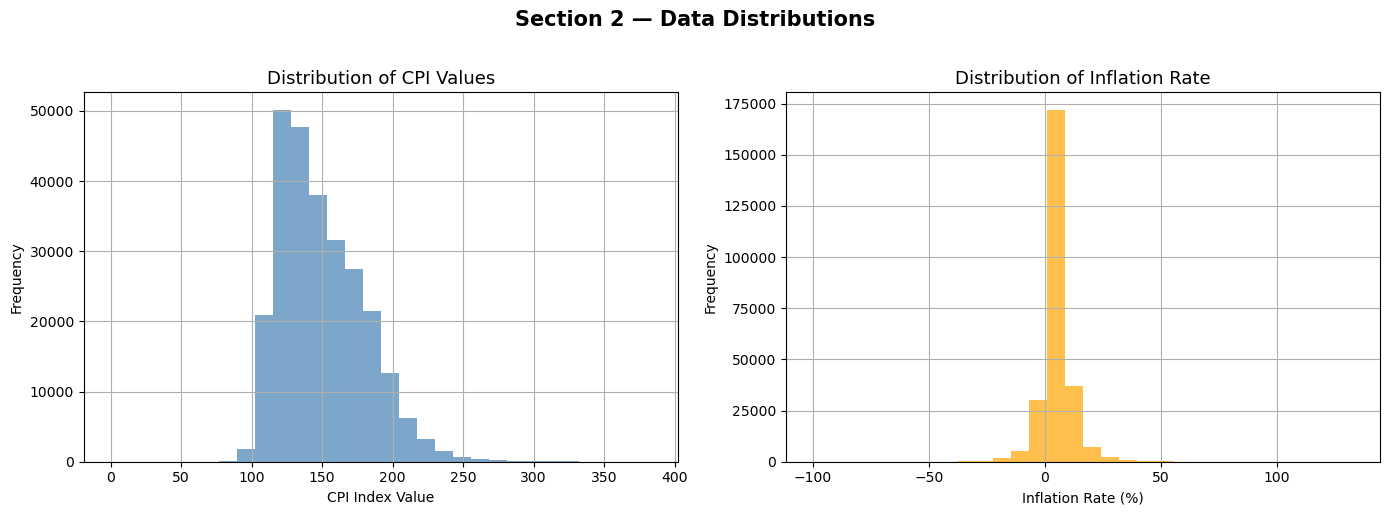


Inflation Shock Flag:
Inflation_shock
0    169319
1    105355
Name: count, dtype: int64
Shock Rate:  38.36 %


In [15]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print("Shape          :", data_features.shape)
print("Date Range     :", data_features['Date'].min(),
      "→", data_features['Date'].max())
print("Duplicates     :", data_features.duplicated().sum())
print("\nData Types:\n",   data_features.dtypes)
print("\nMissing Values:\n", data_features.isnull().sum())
print("\nSummary Statistics:\n", data_features.describe())

# CPI and Inflation distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_features['CPI_value'].hist(
    bins=30, alpha=0.7, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of CPI Values', fontsize=13)
axes[0].set_xlabel('CPI Index Value')
axes[0].set_ylabel('Frequency')

data_features['Inflation_rate'].hist(
    bins=30, alpha=0.7, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Inflation Rate', fontsize=13)
axes[1].set_xlabel('Inflation Rate (%)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Section 2 — Data Distributions', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Shock flag counts
print("\nInflation Shock Flag:")
print(data_features['Inflation_shock'].value_counts())
print("Shock Rate: ",
      round(data_features['Inflation_shock'].mean()*100, 2), "%")

# SECTION 3 | DATA CLEANING

In [16]:
# Step 1: Sort chronologically
data_features = data_features.sort_values('Date').reset_index(drop=True)

# Step 2: Drop rows where lag features are NaN
data_clean = data_features.dropna(
    subset=['CPI_lag_1', 'CPI_lag_3', 'CPI_lag_6']
)
print("After lag dropna:", data_clean.shape)

# Step 3: Filter banking-relevant CPI groups only
banking_groups = [
    'Food and Beverages',
    'Fuel and Light',
    'Housing',
    'Transport and Communication'
]

data_selected = data_clean[
    data_clean['group'].isin(banking_groups)
][[
    'Date', 'group', 'subgroup',
    'CPI_value', 'Inflation_rate',
    'CPI_MoM_change', 'CPI_YoY_change',
    'CPI_rolling_std_6m', 'Inflation_shock',
    'CPI_lag_1', 'CPI_lag_3', 'CPI_lag_6'
]]

# Step 4: Drop rows with any remaining missing core features
final_data = data_selected.dropna(subset=[
    'CPI_value', 'Inflation_rate',
    'CPI_MoM_change', 'CPI_YoY_change',
    'CPI_rolling_std_6m'
]).copy()

print("After final cleaning:", final_data.shape)
print("Total missing values:", final_data.isnull().sum().sum())
print("\nGroup Distribution:")
print(final_data['group'].value_counts())

After lag dropna: (251597, 21)
After final cleaning: (121539, 12)
Total missing values: 0

Group Distribution:
group
Food and Beverages    105178
Fuel and Light         12226
Housing                 4135
Name: count, dtype: int64


# SECTION 4 | CORRELATION ANALYSIS

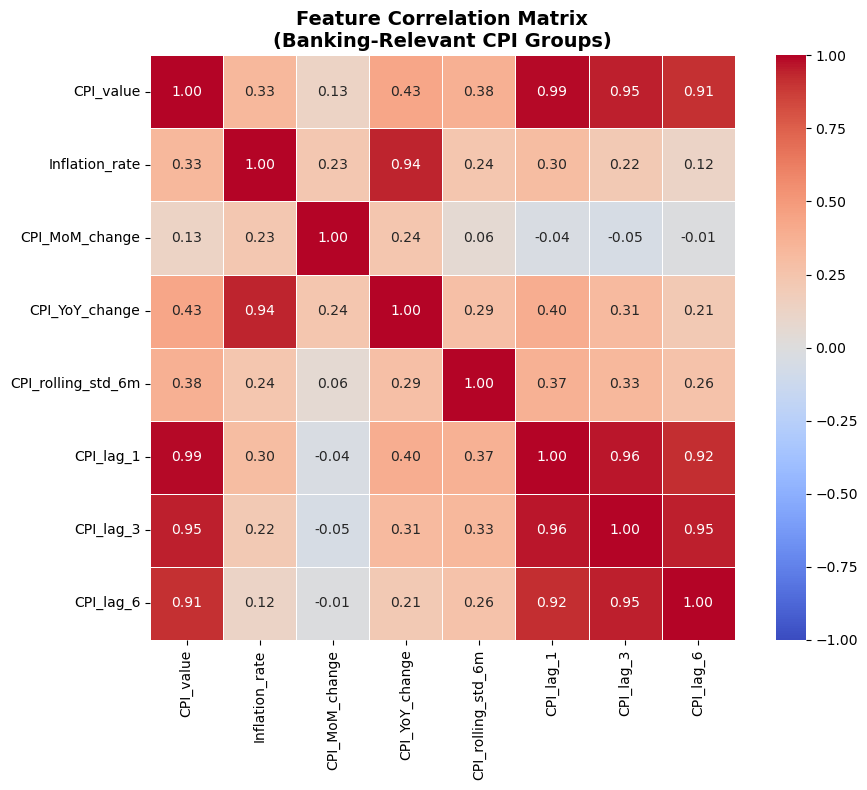

Top Correlations with Inflation_rate:
CPI_YoY_change        0.9396
CPI_value             0.3334
CPI_lag_1             0.2970
CPI_rolling_std_6m    0.2403
CPI_MoM_change        0.2304
CPI_lag_3             0.2181
CPI_lag_6             0.1179
Name: Inflation_rate, dtype: float64


In [17]:
corr_cols = [
    'CPI_value', 'Inflation_rate', 'CPI_MoM_change',
    'CPI_YoY_change', 'CPI_rolling_std_6m',
    'CPI_lag_1', 'CPI_lag_3', 'CPI_lag_6'
]

corr_matrix = final_data[corr_cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    vmin=-1, vmax=1
)
plt.title('Feature Correlation Matrix\n(Banking-Relevant CPI Groups)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top features correlated with Inflation_rate
print("Top Correlations with Inflation_rate:")
print(corr_matrix['Inflation_rate']
      .drop('Inflation_rate')
      .sort_values(ascending=False)
      .round(4))

# ─────────────────────────────────────────────────────────────
# PHASE 2 | Feature Selection
# ─────────────────────────────────────────────────────────────

## SECTION 6 | FEATURE SELECTION — STEP 1: VARIANCE THRESHOLD

VARIANCE THRESHOLD RESULTS
Threshold applied : 0.1 (on standardised features)
Features before   : 8
Features removed  : None
Features retained : 8
Retained list     : ['CPI_value', 'Inflation_rate', 'CPI_MoM_change', 'CPI_YoY_change', 'CPI_rolling_std_6m', 'CPI_lag_1', 'CPI_lag_3', 'CPI_lag_6']


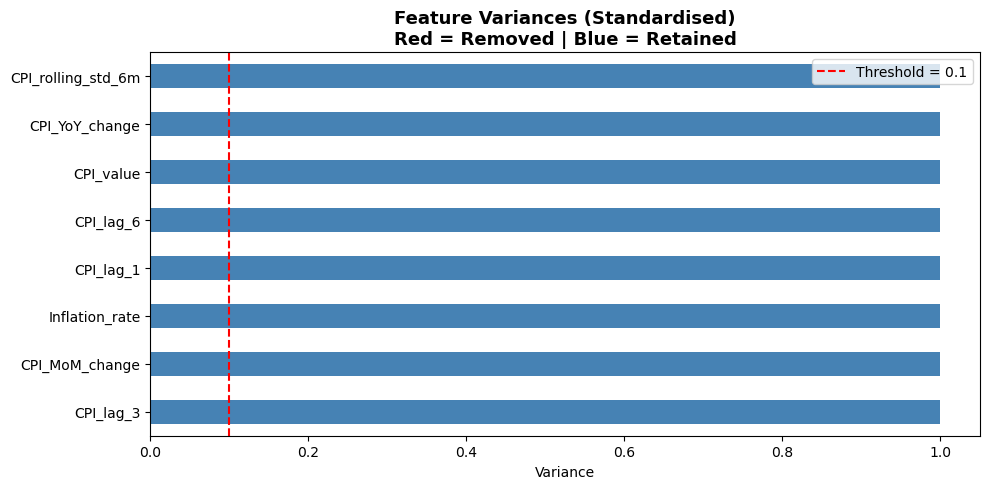

In [8]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

# Define candidate features for anomaly detection
candidate_features = [
    'CPI_value', 'Inflation_rate', 'CPI_MoM_change',
    'CPI_YoY_change', 'CPI_rolling_std_6m',
    'CPI_lag_1', 'CPI_lag_3', 'CPI_lag_6'
]

# Aggregate to monthly level (one row per month)
macro_data = final_data.groupby(final_data.index)[
    candidate_features
].mean().dropna()

# Step 1: Standardise before applying threshold
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(macro_data[candidate_features])
X_scaled_df = pd.DataFrame(
    X_scaled, columns=candidate_features, index=macro_data.index
)

# Step 2: Apply Variance Threshold (threshold=0.1 on scaled data)
vt      = VarianceThreshold(threshold=0.1)
vt.fit(X_scaled_df)

# Results
variances       = pd.Series(vt.variances_, index=candidate_features)
retained_mask   = vt.get_support()
retained_after_vt = list(
    X_scaled_df.columns[retained_mask]
)
removed_vt = list(
    X_scaled_df.columns[~retained_mask]
)

print("="*52)
print("VARIANCE THRESHOLD RESULTS")
print("="*52)
print(f"Threshold applied : 0.1 (on standardised features)")
print(f"Features before   : {len(candidate_features)}")
print(f"Features removed  : {removed_vt if removed_vt else 'None'}")
print(f"Features retained : {len(retained_after_vt)}")
print(f"Retained list     : {retained_after_vt}")

# Visualise variances
plt.figure(figsize=(10, 5))
colors = ['crimson' if v < 0.1 else 'steelblue'
          for v in variances]
variances.sort_values().plot(kind='barh', color=colors)
plt.axvline(0.1, color='red', linestyle='--',
            linewidth=1.5, label='Threshold = 0.1')
plt.title('Feature Variances (Standardised)\n'
          'Red = Removed | Blue = Retained',
          fontsize=13, fontweight='bold')
plt.xlabel('Variance')
plt.legend()
plt.tight_layout()
plt.show()

## SECTION 6 | FEATURE SELECTION — STEP 2: CORRELATION FILTER

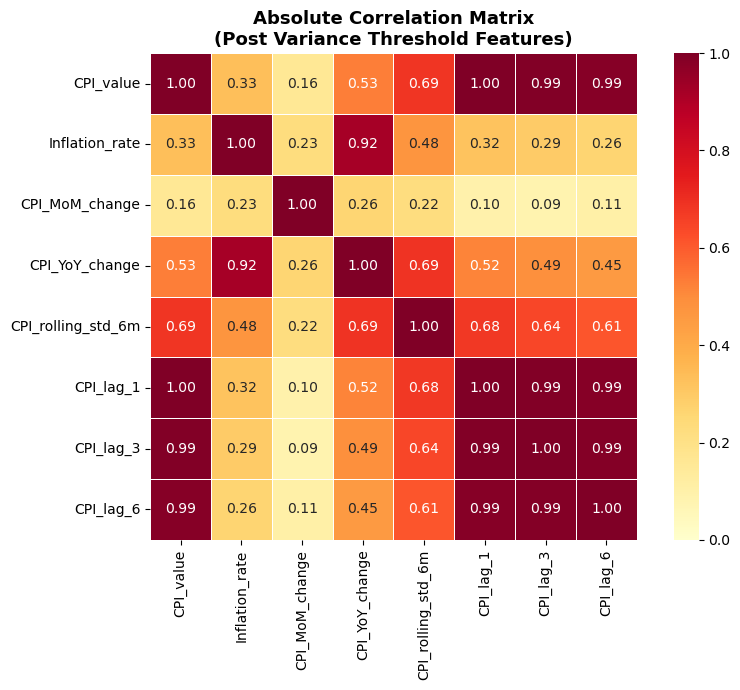

CORRELATION FILTER RESULTS
Correlation threshold : 0.85
Features before       : 8
Features removed      : ['CPI_lag_3', 'CPI_YoY_change', 'CPI_lag_1', 'CPI_value']
Features retained     : 4
Retained list         : ['Inflation_rate', 'CPI_MoM_change', 'CPI_rolling_std_6m', 'CPI_lag_6']

Highly Correlated Pairs Detected (>0.85):
  CPI_YoY_change  ↔  Inflation_rate  (r = 0.920)
  CPI_lag_1  ↔  CPI_value  (r = 0.998)
  CPI_lag_3  ↔  CPI_value  (r = 0.992)
  CPI_lag_3  ↔  CPI_lag_1  (r = 0.995)
  CPI_lag_6  ↔  CPI_value  (r = 0.986)
  CPI_lag_6  ↔  CPI_lag_1  (r = 0.987)
  CPI_lag_6  ↔  CPI_lag_3  (r = 0.992)


In [19]:
# Work with features retained after Variance Threshold
X_vt = X_scaled_df[retained_after_vt]

# Compute absolute correlation matrix
corr_matrix = X_vt.corr().abs()

# Visualise correlation of retained features
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    square=True,
    vmin=0, vmax=1
)
plt.title('Absolute Correlation Matrix\n(Post Variance Threshold Features)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify and remove highly correlated features (threshold > 0.85)
corr_threshold = 0.85
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# For each correlated pair, drop the one with higher
# mean absolute correlation (less unique)
to_drop = set()
for col in upper_triangle.columns:
    correlated_with = upper_triangle.index[
        upper_triangle[col] > corr_threshold
    ].tolist()
    if correlated_with:
        # Compare mean correlation of col vs its partners
        for partner in correlated_with:
            mean_col     = corr_matrix[col].mean()
            mean_partner = corr_matrix[partner].mean()
            # Drop the one more correlated with everything else
            if mean_col >= mean_partner:
                to_drop.add(col)
            else:
                to_drop.add(partner)

retained_after_corr  = [
    f for f in retained_after_vt if f not in to_drop
]

print("="*52)
print("CORRELATION FILTER RESULTS")
print("="*52)
print(f"Correlation threshold : 0.85")
print(f"Features before       : {len(retained_after_vt)}")
print(f"Features removed      : {list(to_drop) if to_drop else 'None'}")
print(f"Features retained     : {len(retained_after_corr)}")
print(f"Retained list         : {retained_after_corr}")

# Show the highly correlated pairs found
print("\nHighly Correlated Pairs Detected (>0.85):")
found_any = False
for col in upper_triangle.columns:
    partners = upper_triangle.index[
        upper_triangle[col] > corr_threshold
    ].tolist()
    if partners:
        for p in partners:
            print(f"  {col}  ↔  {p}  "
                  f"(r = {corr_matrix.loc[col, p]:.3f})")
        found_any = True
if not found_any:
    print("  None found above threshold")

## SECTION 7 | FEATURE SELECTION — STEP 3: PCA VARIANCE ANALYSIS

PCA — VARIANCE EXPLAINED
  PC1: 50.44% variance  | Cumulative: 50.44%
  PC2: 23.59% variance  | Cumulative: 74.03%
  PC3: 17.58% variance  | Cumulative: 91.62%
  PC4: 8.38% variance  | Cumulative: 100.00%

→ Components needed for 95% variance: 4


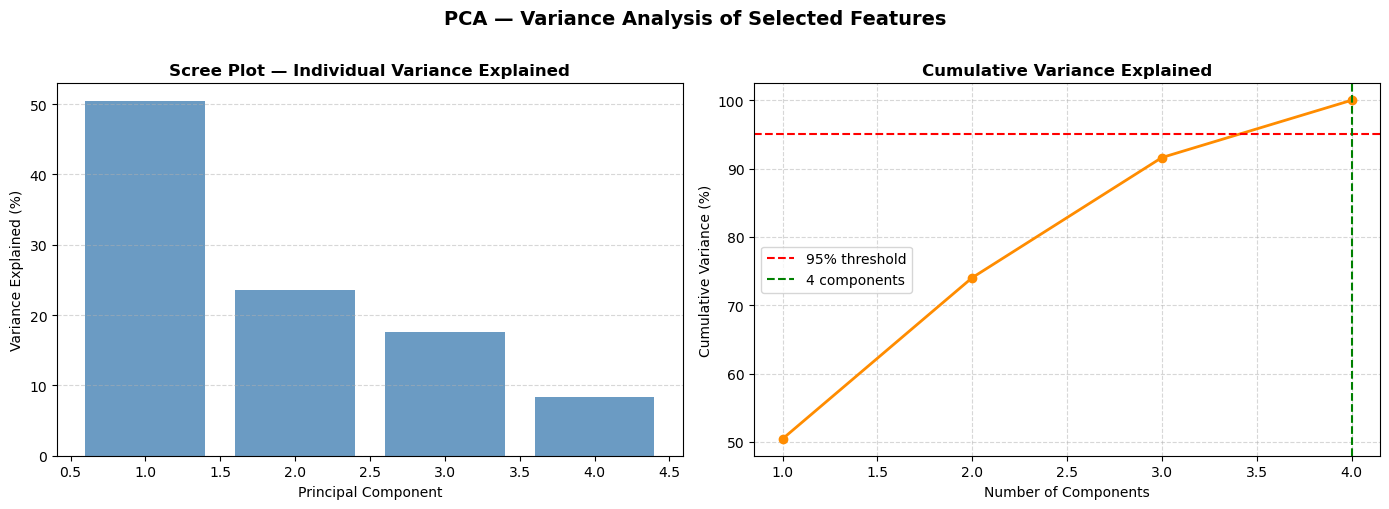

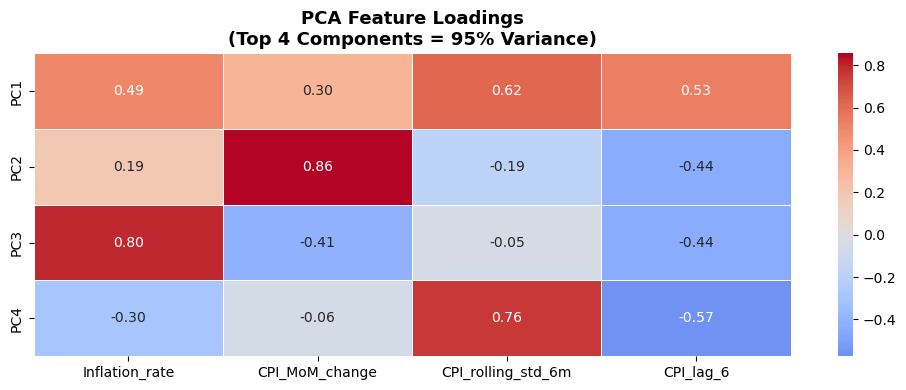


Interpretation Guide:
  High positive loading → feature strongly drives this PC upward
  High negative loading → feature drives this PC downward
  Near zero            → feature barely influences this PC


In [20]:
from sklearn.decomposition import PCA

# Work with final retained features
X_final_pre_pca = X_scaled_df[retained_after_corr].values
feature_names   = retained_after_corr

# Fit full PCA (all components)
pca_full     = PCA()
pca_full.fit(X_final_pre_pca)

explained_var      = pca_full.explained_variance_ratio_
cumulative_var     = np.cumsum(explained_var)
n_components_95    = np.argmax(cumulative_var >= 0.95) + 1

print("="*52)
print("PCA — VARIANCE EXPLAINED")
print("="*52)
for i, (ev, cv) in enumerate(
    zip(explained_var, cumulative_var), 1
):
    print(f"  PC{i}: {ev*100:.2f}% variance  "
          f"| Cumulative: {cv*100:.2f}%")
print(f"\n→ Components needed for 95% variance: {n_components_95}")

# ── Plot 1: Scree Plot + Cumulative Variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained_var)+1),
            explained_var*100, color='steelblue', alpha=0.8)
axes[0].set_title('Scree Plot — Individual Variance Explained',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].plot(range(1, len(cumulative_var)+1),
             cumulative_var*100, marker='o',
             linewidth=2, color='darkorange')
axes[1].axhline(95, color='red', linestyle='--',
                label='95% threshold')
axes[1].axvline(n_components_95, color='green',
                linestyle='--',
                label=f'{n_components_95} components')
axes[1].set_title('Cumulative Variance Explained',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.5)

plt.suptitle('PCA — Variance Analysis of Selected Features',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Plot 2: Feature Loadings Heatmap (which features drive which PC)
loadings = pd.DataFrame(
    pca_full.components_[:n_components_95],
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(n_components_95)]
)

plt.figure(figsize=(10, 4))
sns.heatmap(
    loadings,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    center=0
)
plt.title(f'PCA Feature Loadings\n'
          f'(Top {n_components_95} Components = 95% Variance)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretation Guide:")
print("  High positive loading → feature strongly drives this PC upward")
print("  High negative loading → feature drives this PC downward")
print("  Near zero            → feature barely influences this PC")

## SECTION 8 | FEATURE SELECTION — FINAL SELECTED FEATURE SET

FEATURE SELECTION PIPELINE — SUMMARY
                           Stage  Count                                                                                                       Features
             Original Candidates      8 CPI_value, Inflation_rate, CPI_MoM_change, CPI_YoY_change, CPI_rolling_std_6m, CPI_lag_1, CPI_lag_3, CPI_lag_6
 After Variance Threshold (>0.1)      8 CPI_value, Inflation_rate, CPI_MoM_change, CPI_YoY_change, CPI_rolling_std_6m, CPI_lag_1, CPI_lag_3, CPI_lag_6
After Correlation Filter (<0.85)      4                                                  Inflation_rate, CPI_MoM_change, CPI_rolling_std_6m, CPI_lag_6
         Final Selected Features      4                                                  Inflation_rate, CPI_MoM_change, CPI_rolling_std_6m, CPI_lag_6


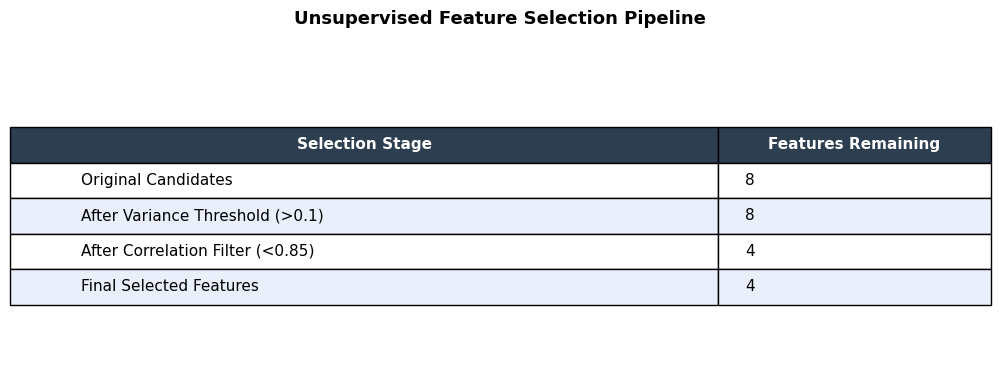


✅ SELECTED_FEATURES locked: ['Inflation_rate', 'CPI_MoM_change', 'CPI_rolling_std_6m', 'CPI_lag_6']
✅ X_anomaly_input shape   : (118, 4)

All anomaly detection models (Sections 10–14)
will use X_anomaly_input as their input.


In [21]:
# ── Final feature set locked for all anomaly detection models
SELECTED_FEATURES = retained_after_corr

print("="*55)
print("FEATURE SELECTION PIPELINE — SUMMARY")
print("="*55)

pipeline_summary = pd.DataFrame({
    'Stage': [
        'Original Candidates',
        'After Variance Threshold (>0.1)',
        'After Correlation Filter (<0.85)',
        'Final Selected Features'
    ],
    'Count': [
        len(candidate_features),
        len(retained_after_vt),
        len(retained_after_corr),
        len(SELECTED_FEATURES)
    ],
    'Features': [
        ', '.join(candidate_features),
        ', '.join(retained_after_vt),
        ', '.join(retained_after_corr),
        ', '.join(SELECTED_FEATURES)
    ]
})

print(pipeline_summary.to_string(index=False))

# ── Visual summary
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
tbl = ax.table(
    cellText=pipeline_summary[['Stage','Count']].values,
    colLabels=['Selection Stage', 'Features Remaining'],
    cellLoc='left', loc='center',
    colWidths=[0.65, 0.25]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 2.0)

# Style header row
for j in range(2):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Style data rows alternately
for i in range(1, len(pipeline_summary)+1):
    for j in range(2):
        tbl[i, j].set_facecolor(
            '#eaf0fb' if i % 2 == 0 else 'white'
        )

plt.title('Unsupervised Feature Selection Pipeline',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ── Prepare the clean scaled matrix for anomaly models
X_anomaly_input = X_scaled_df[SELECTED_FEATURES]

print(f"\n✅ SELECTED_FEATURES locked: {SELECTED_FEATURES}")
print(f"✅ X_anomaly_input shape   : {X_anomaly_input.shape}")
print("\nAll anomaly detection models (Sections 10–14)")
print("will use X_anomaly_input as their input.")

# ─────────────────────────────────────────────────────────────
# PHASE 3 | Time Series Properties
# ─────────────────────────────────────────────────────────────

Index type  : <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index name  : Date
Date range  : 2015-01-01 00:00:00 → 2024-12-01 00:00:00
Shape       : (121539, 11)
Columns     : ['group', 'subgroup', 'CPI_value', 'Inflation_rate', 'CPI_MoM_change', 'CPI_YoY_change', 'CPI_rolling_std_6m', 'Inflation_shock', 'CPI_lag_1', 'CPI_lag_3', 'CPI_lag_6']

Time series shape : (118,)
First 5 values    :
 Date
2015-01-01    5.430480
2015-02-01    5.851708
2015-03-01    5.580018
2015-04-01    5.024247
2015-05-01    5.137036
Name: Inflation_rate, dtype: float64
Last  5 values    :
 Date
2024-08-01    3.416722
2024-09-01    5.681330
2024-10-01    6.491265
2024-11-01    5.556491
2024-12-01    5.607784
Name: Inflation_rate, dtype: float64


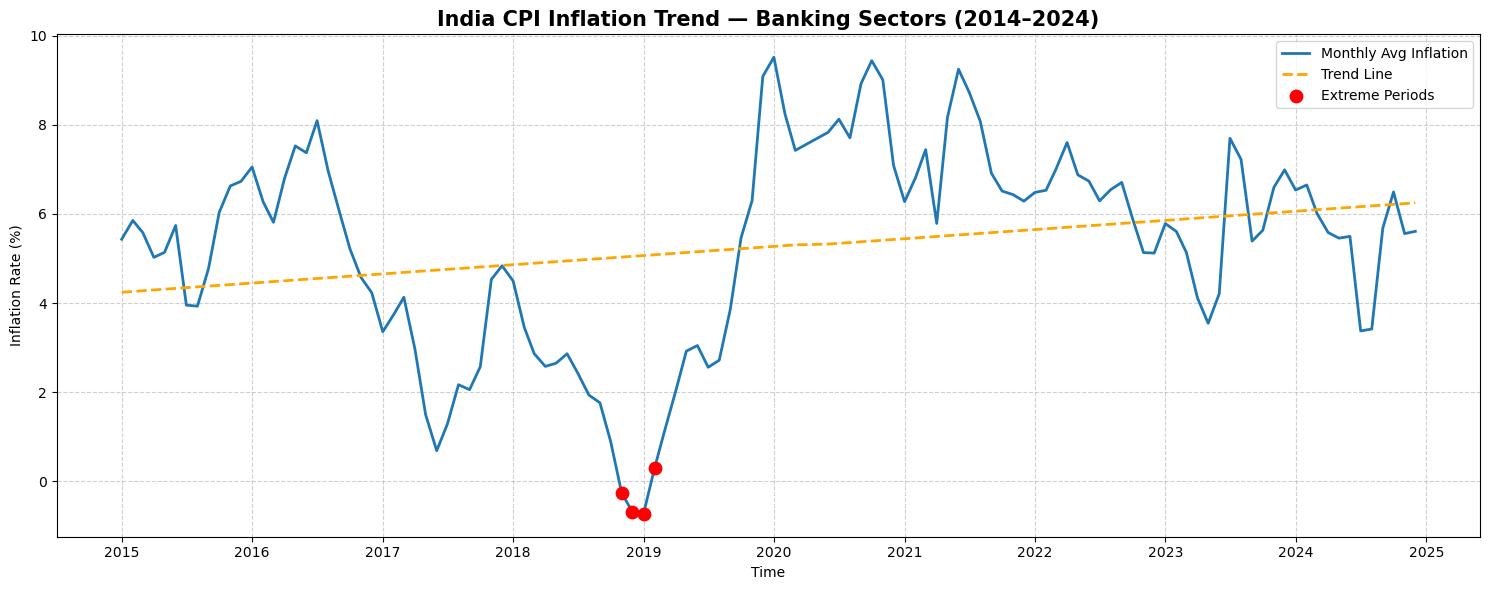

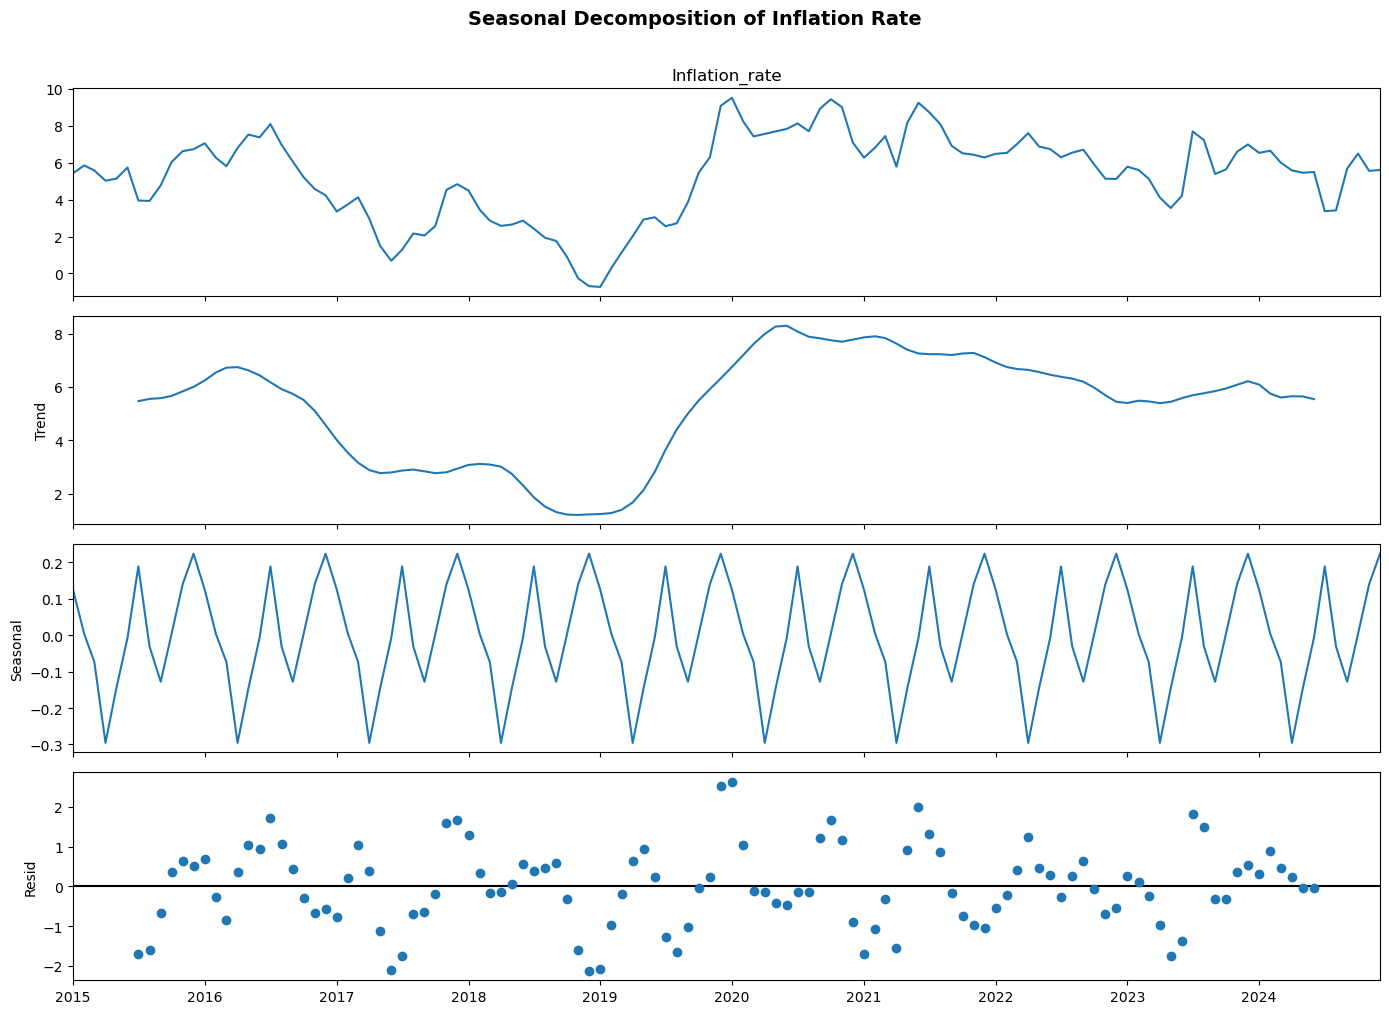

Decomposition Interpretation:
  Trend    → Long-run inflation direction
  Seasonal → Stable 12-month yearly cycle
  Residual → Unexplained shocks → ANOMALY SIGNALS in Sections 11-12

ADF TEST — ORIGINAL SERIES
ADF Statistic : -1.6547
p-value       : 0.454567
  Critical 1% : -3.4930
  Critical 5% : -2.8890
  Critical 10% : -2.5814
→ NON-STATIONARY → differencing required


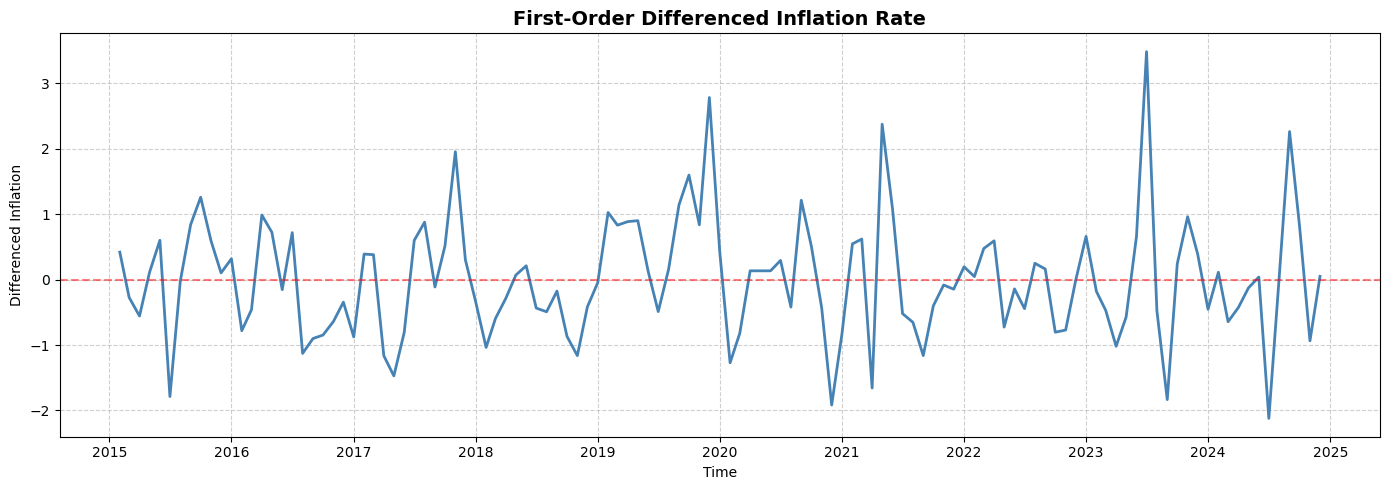


ADF TEST — DIFFERENCED SERIES
ADF Statistic : -4.1371
p-value       : 0.000840
→ NOW STATIONARY — d = 1 confirmed for ARIMA/SARIMA


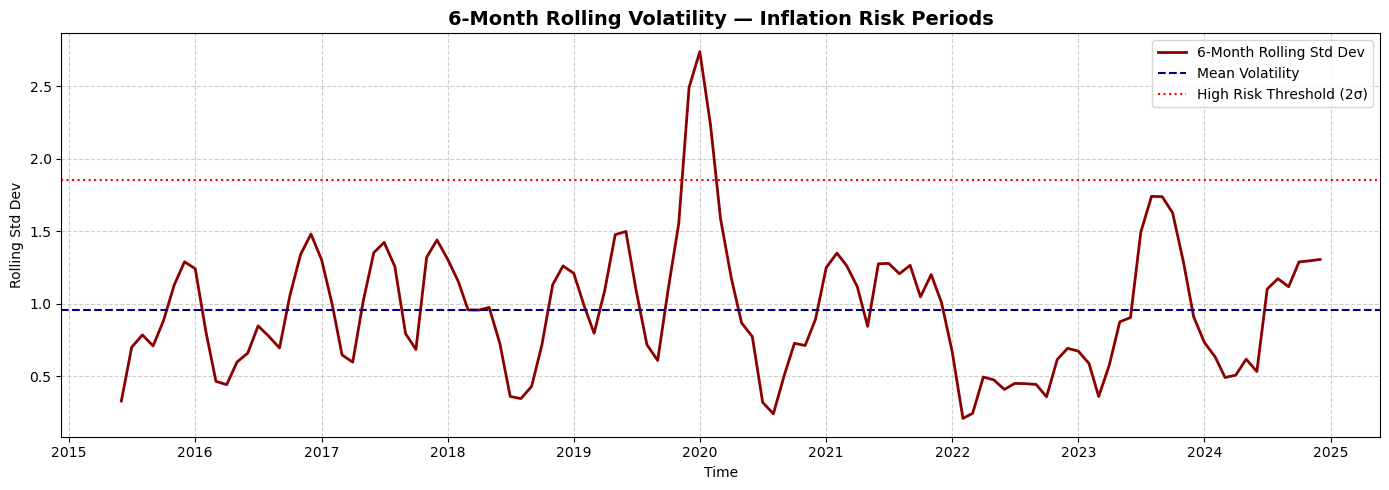


✅ Section 9 complete
   ts_ms shape  : (120,)
   ts_diff shape: (119,)
   Both ready for ARIMA / SARIMA / GARCH in Sections 11–13


In [24]:
# ─────────────────────────────────────────────────────────────
# SECTION 9 | TIME SERIES PROPERTIES — FIXED DATE HANDLING
# ─────────────────────────────────────────────────────────────
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# ── SAFE DATE FIX — handles all cases ────────────────────────

# Step 1: Reset index so Date becomes a column again (safe even
#         if index is already integer — won't break anything)
final_data = final_data.reset_index()

# Step 2: Rename 'index' to 'Date' only if needed
if 'index' in final_data.columns and 'Date' not in final_data.columns:
    final_data = final_data.rename(columns={'index': 'Date'})

# Step 3: Force Date to datetime (safe even if already datetime)
final_data['Date'] = pd.to_datetime(final_data['Date'])

# Step 4: Drop any duplicate Date column if it exists
final_data = final_data.loc[:, ~final_data.columns.duplicated()]

# Step 5: Set Date as index cleanly
final_data = final_data.set_index('Date').sort_index()

# Confirm fix
print("Index type  :", type(final_data.index))
print("Index name  :", final_data.index.name)
print("Date range  :", final_data.index.min(), "→", final_data.index.max())
print("Shape       :", final_data.shape)
print("Columns     :", list(final_data.columns))

# ── Now build the monthly time series safely ─────────────────
ts = final_data.groupby(final_data.index)['Inflation_rate'].mean()

# Ensure DatetimeIndex with monthly frequency
ts.index = pd.to_datetime(ts.index)
ts       = ts.sort_index()

print("\nTime series shape :", ts.shape)
print("First 5 values    :\n", ts.head())
print("Last  5 values    :\n", ts.tail())

# ── 9a. Inflation Trend ───────────────────────────────────────
x        = np.arange(len(ts))
trend    = np.poly1d(np.polyfit(x, ts, 1))
extremes = ts[abs(ts - ts.mean()) > 2*ts.std()]

plt.figure(figsize=(15, 6))
plt.plot(ts, linewidth=2, label='Monthly Avg Inflation')
plt.plot(ts.index, trend(x), linestyle='--',
         linewidth=2, color='orange', label='Trend Line')
plt.scatter(extremes.index, extremes, s=80,
            color='red', zorder=5, label='Extreme Periods')
plt.title("India CPI Inflation Trend — Banking Sectors (2014–2024)",
          fontsize=15, fontweight='bold')
plt.xlabel("Time"); plt.ylabel("Inflation Rate (%)")
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

# ── 9b. Seasonal Decomposition ────────────────────────────────
# Need clean evenly-spaced monthly series for decomposition
ts_clean = ts.resample('MS').mean().interpolate()

decomp = seasonal_decompose(ts_clean, model='additive', period=12)
fig    = decomp.plot()
fig.set_size_inches(14, 10)
plt.suptitle("Seasonal Decomposition of Inflation Rate",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print("Decomposition Interpretation:")
print("  Trend    → Long-run inflation direction")
print("  Seasonal → Stable 12-month yearly cycle")
print("  Residual → Unexplained shocks → ANOMALY SIGNALS in Sections 11-12")

# ── 9c. ADF Test — Original Series ───────────────────────────
print("\n" + "="*48)
print("ADF TEST — ORIGINAL SERIES")
print("="*48)
adf = adfuller(ts_clean.dropna())
print(f"ADF Statistic : {adf[0]:.4f}")
print(f"p-value       : {adf[1]:.6f}")
for k, v in adf[4].items():
    print(f"  Critical {k} : {v:.4f}")
if adf[1] > 0.05:
    print("→ NON-STATIONARY → differencing required")
else:
    print("→ STATIONARY")

# ── 9d. First-Order Differencing ─────────────────────────────
ts_diff = ts_clean.diff().dropna()

plt.figure(figsize=(14, 5))
plt.plot(ts_diff, linewidth=2, color='steelblue')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title("First-Order Differenced Inflation Rate",
          fontsize=14, fontweight='bold')
plt.xlabel("Time"); plt.ylabel("Differenced Inflation")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

adf2 = adfuller(ts_diff)
print("\n" + "="*48)
print("ADF TEST — DIFFERENCED SERIES")
print("="*48)
print(f"ADF Statistic : {adf2[0]:.4f}")
print(f"p-value       : {adf2[1]:.6f}")
if adf2[1] < 0.05:
    print("→ NOW STATIONARY — d = 1 confirmed for ARIMA/SARIMA")
else:
    print("→ Still non-stationary — consider d = 2")

# ── 9e. Rolling Volatility ────────────────────────────────────
ts_interp   = ts_clean.copy()
rolling_vol = ts_interp.rolling(window=6).std()

plt.figure(figsize=(14, 5))
plt.plot(rolling_vol, linewidth=2, color='darkred',
         label='6-Month Rolling Std Dev')
plt.axhline(rolling_vol.mean(), color='navy',
            linestyle='--', label='Mean Volatility')
plt.axhline(rolling_vol.mean() + 2*rolling_vol.std(),
            color='red', linestyle=':',
            label='High Risk Threshold (2σ)')
plt.title("6-Month Rolling Volatility — Inflation Risk Periods",
          fontsize=14, fontweight='bold')
plt.xlabel("Time"); plt.ylabel("Rolling Std Dev")
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

# ── Store clean series for Sections 10–14 ────────────────────
ts_ms = ts_clean.copy()   # clean monthly series, evenly spaced

print("\n✅ Section 9 complete")
print("   ts_ms shape  :", ts_ms.shape)
print("   ts_diff shape:", ts_diff.shape)
print("   Both ready for ARIMA / SARIMA / GARCH in Sections 11–13")

# ─────────────────────────────────────────────────────────────
# PHASE 4 | Anomaly Detection
# ─────────────────────────────────────────────────────────────

## SECTION 10 | METHOD 1 — Z-SCORE ANOMALY DETECTION

METHOD 1 — Z-SCORE ANOMALY DETECTION
Mean Inflation : 5.2445%
Std Deviation  : 2.3029%
Threshold      : ±2σ
Anomalies Found: 4
Anomaly Dates  :
Date
2018-11-01   -0.2663
2018-12-01   -0.6833
2019-01-01   -0.7294
2019-02-01    0.2982
Name: Inflation_rate, dtype: float64


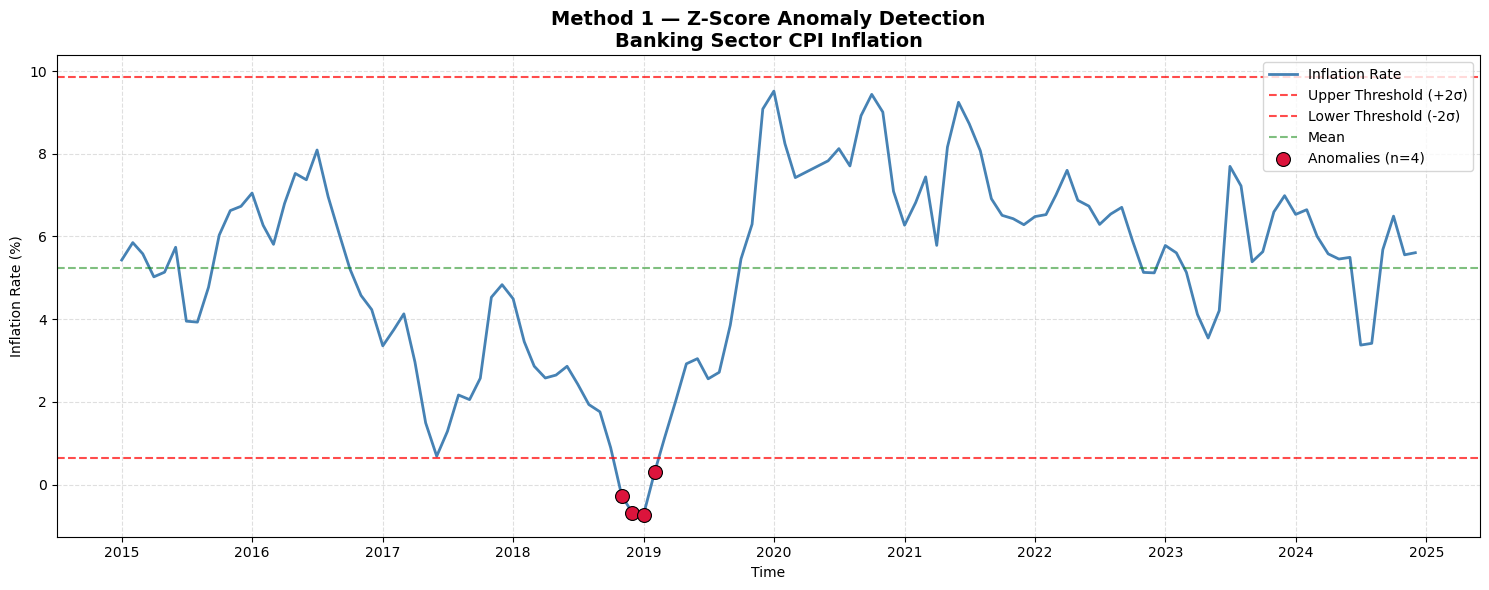


→ Z-Score anomaly dates stored for comparison table


In [25]:
z_scores    = (ts - ts.mean()) / ts.std()
z_anomalies = ts[abs(z_scores) > 2].index

print("="*48)
print("METHOD 1 — Z-SCORE ANOMALY DETECTION")
print("="*48)
print(f"Mean Inflation : {ts.mean():.4f}%")
print(f"Std Deviation  : {ts.std():.4f}%")
print(f"Threshold      : ±2σ")
print(f"Anomalies Found: {len(z_anomalies)}")
print(f"Anomaly Dates  :\n{ts[z_anomalies].round(4)}")

plt.figure(figsize=(15, 6))
plt.plot(ts, linewidth=2, color='steelblue',
         label='Inflation Rate')
plt.axhline(ts.mean() + 2*ts.std(), color='red',
            linestyle='--', alpha=0.7, label='Upper Threshold (+2σ)')
plt.axhline(ts.mean() - 2*ts.std(), color='red',
            linestyle='--', alpha=0.7, label='Lower Threshold (-2σ)')
plt.axhline(ts.mean(), color='green',
            linestyle='--', alpha=0.5, label='Mean')
plt.scatter(z_anomalies, ts[z_anomalies],
            color='crimson', s=100, zorder=5,
            edgecolor='black', linewidth=0.8,
            label=f'Anomalies (n={len(z_anomalies)})')
plt.title("Method 1 — Z-Score Anomaly Detection\n"
          "Banking Sector CPI Inflation",
          fontsize=14, fontweight='bold')
plt.xlabel("Time"); plt.ylabel("Inflation Rate (%)")
plt.legend(); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

# Store results
zscore_anomaly_dates = set(z_anomalies)
print(f"\n→ Z-Score anomaly dates stored for comparison table")

## SECTION 11 | METHOD 2 — ARIMA RESIDUAL ANOMALIES

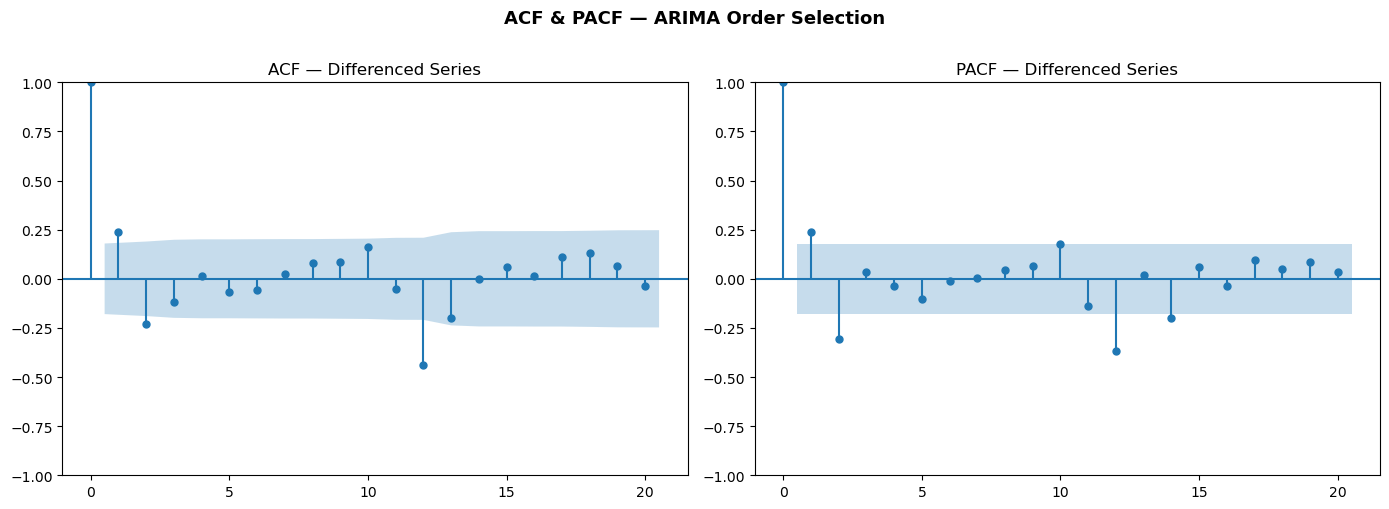

                               SARIMAX Results                                
Dep. Variable:         Inflation_rate   No. Observations:                  120
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -150.937
Date:                Wed, 04 Mar 2026   AIC                            307.874
Time:                        00:55:57   BIC                            316.211
Sample:                    01-01-2015   HQIC                           311.259
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2008      0.252     -0.797      0.426      -0.695       0.293
ma.L1          0.5559      0.227      2.451      0.014       0.111       1.001
sigma2         0.7389      0.066     11.260      0.0

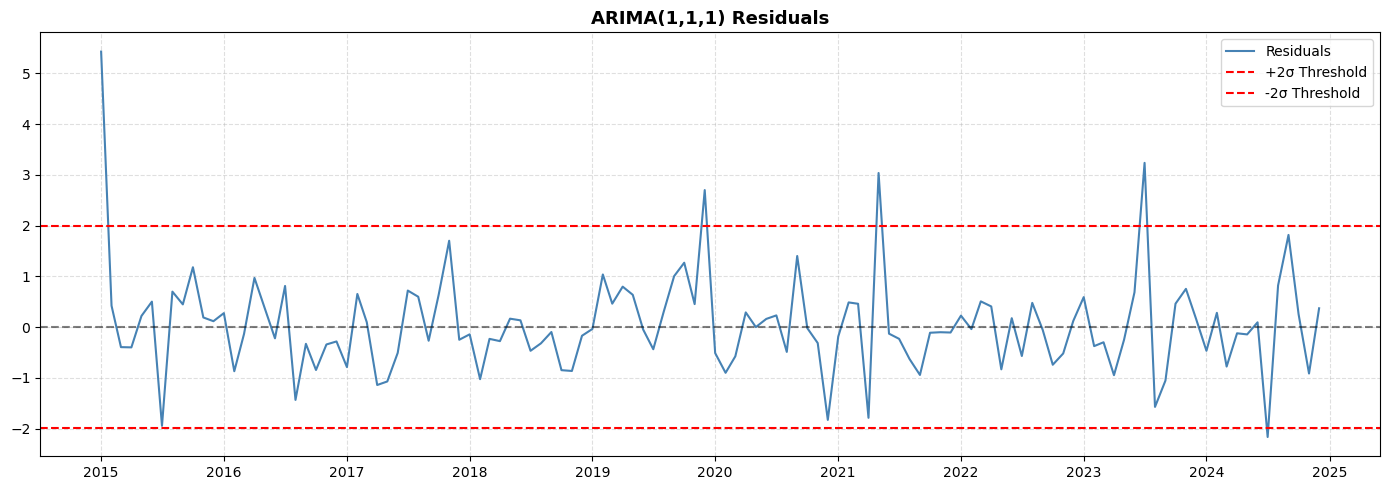

METHOD 2 — ARIMA RESIDUAL ANOMALIES
Residual Std  : 0.9923
Threshold     : ±2σ = ±1.9846
Anomalies     : 5
Anomaly Dates :
Date
2015-01-01    5.4305
2019-12-01    2.7013
2021-05-01    3.0379
2023-07-01    3.2376
2024-07-01   -2.1655
dtype: float64


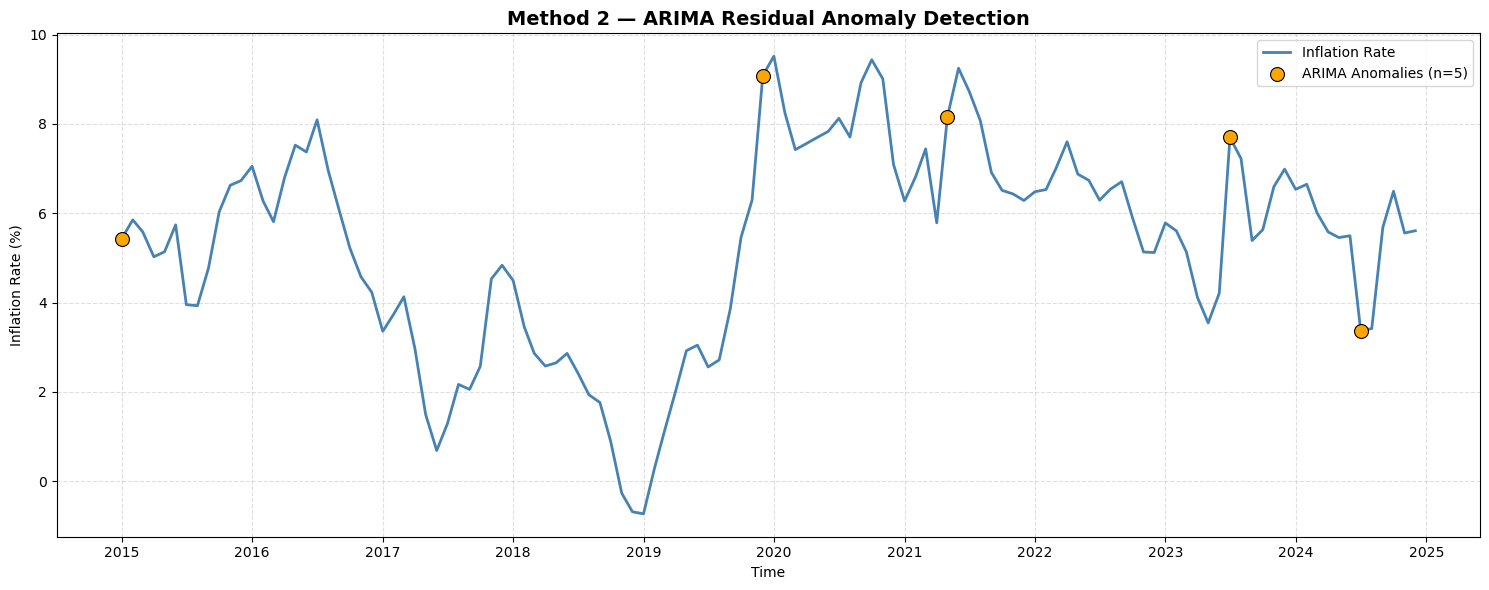


→ ARIMA anomaly dates stored for comparison table


In [26]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── ACF / PACF to confirm ARIMA order
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(ts_diff, ax=axes[0], lags=20)
axes[0].set_title("ACF — Differenced Series")
plot_pacf(ts_diff, ax=axes[1], lags=20)
axes[1].set_title("PACF — Differenced Series")
plt.suptitle("ACF & PACF — ARIMA Order Selection",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

# ── Fit ARIMA(1,1,1)
arima_fit = ARIMA(ts_ms, order=(1, 1, 1)).fit()
print(arima_fit.summary())

arima_res = arima_fit.resid.dropna()

# ── Residual Plot
plt.figure(figsize=(14, 5))
plt.plot(arima_res, linewidth=1.5, color='steelblue',
         label='Residuals')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.axhline(2*arima_res.std(), color='red',
            linestyle='--', label='+2σ Threshold')
plt.axhline(-2*arima_res.std(), color='red',
            linestyle='--', label='-2σ Threshold')
plt.title("ARIMA(1,1,1) Residuals",
          fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

# ── Anomaly Detection via Residuals
arima_threshold = 2 * arima_res.std()
arima_anoms     = arima_res[abs(arima_res) > arima_threshold]

print("="*48)
print("METHOD 2 — ARIMA RESIDUAL ANOMALIES")
print("="*48)
print(f"Residual Std  : {arima_res.std():.4f}")
print(f"Threshold     : ±2σ = ±{arima_threshold:.4f}")
print(f"Anomalies     : {len(arima_anoms)}")
print(f"Anomaly Dates :\n{arima_anoms.round(4)}")

plt.figure(figsize=(15, 6))
plt.plot(ts_ms, linewidth=2, color='steelblue',
         label='Inflation Rate')
plt.scatter(arima_anoms.index,
            ts_ms.reindex(arima_anoms.index),
            color='orange', s=100, zorder=5,
            edgecolor='black', linewidth=0.8,
            label=f'ARIMA Anomalies (n={len(arima_anoms)})')
plt.title("Method 2 — ARIMA Residual Anomaly Detection",
          fontsize=14, fontweight='bold')
plt.xlabel("Time"); plt.ylabel("Inflation Rate (%)")
plt.legend(); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

# Store results
arima_anomaly_dates = set(arima_anoms.index)
print(f"\n→ ARIMA anomaly dates stored for comparison table")

## SECTION 12 | METHOD 3 — SARIMA RESIDUAL ANOMALIES

                                     SARIMAX Results                                      
Dep. Variable:                     Inflation_rate   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -121.928
Date:                            Wed, 04 Mar 2026   AIC                            253.856
Time:                                    00:58:14   BIC                            266.519
Sample:                                01-01-2015   HQIC                           258.969
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2093      0.331     -0.633      0.527      -0.857       0.439
ma.L1          0.5917      0.289   

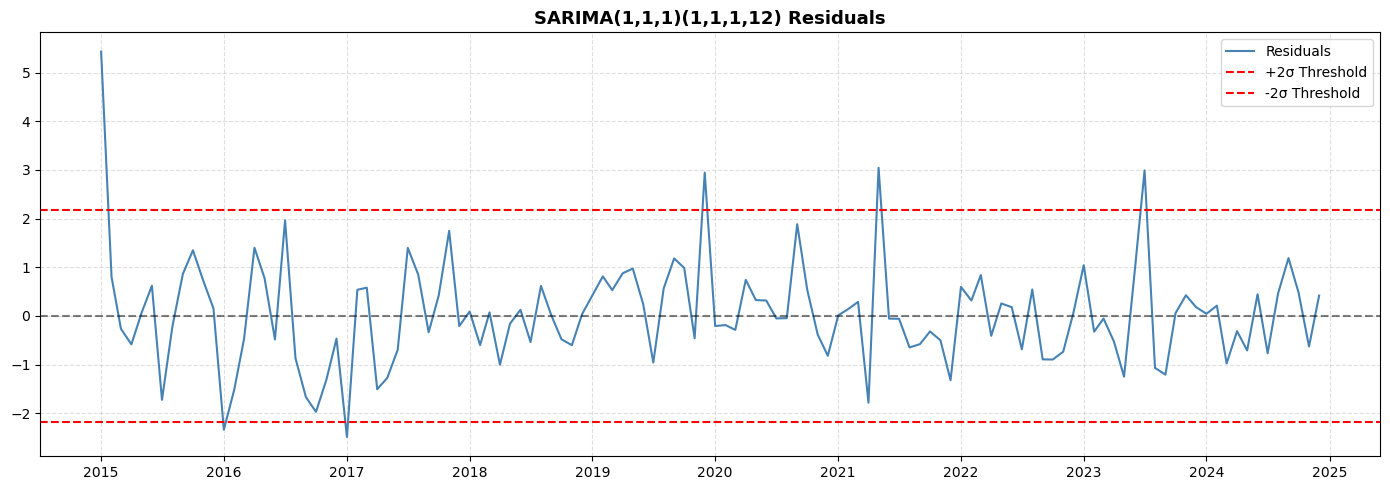

METHOD 3 — SARIMA RESIDUAL ANOMALIES
Residual Std  : 1.0917
Threshold     : ±2σ = ±2.1834
Anomalies     : 6
Anomaly Dates :
Date
2015-01-01    5.4305
2016-01-01   -2.3386
2017-01-01   -2.4888
2019-12-01    2.9452
2021-05-01    3.0431
2023-07-01    2.9896
dtype: float64


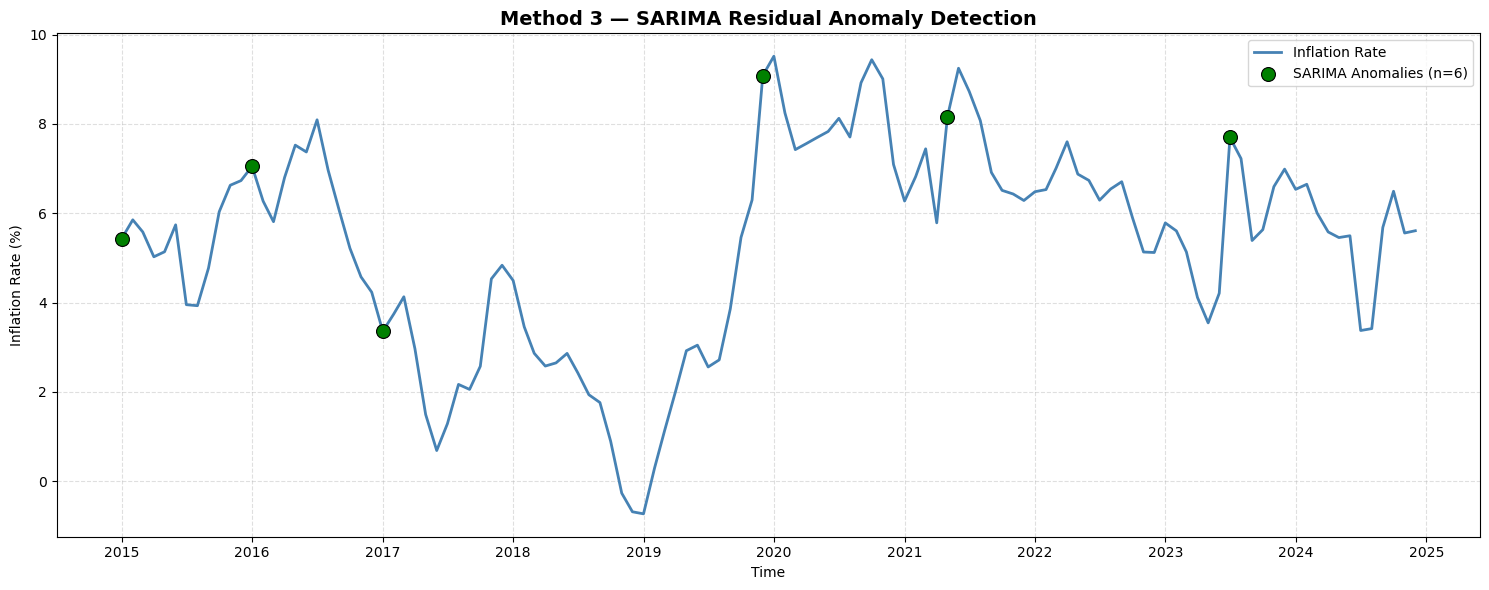


→ SARIMA anomaly dates stored for comparison table


In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ── Fit SARIMA(1,1,1)(1,1,1,12)
sarima_fit = SARIMAX(
    ts_ms, order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
print(sarima_fit.summary())

sarima_res = sarima_fit.resid.dropna()

# ── Residual Plot
plt.figure(figsize=(14, 5))
plt.plot(sarima_res, linewidth=1.5, color='steelblue',
         label='Residuals')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.axhline(2*sarima_res.std(), color='red',
            linestyle='--', label='+2σ Threshold')
plt.axhline(-2*sarima_res.std(), color='red',
            linestyle='--', label='-2σ Threshold')
plt.title("SARIMA(1,1,1)(1,1,1,12) Residuals",
          fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

# ── Anomaly Detection
sarima_threshold = 2 * sarima_res.std()
sarima_anoms     = sarima_res[abs(sarima_res) > sarima_threshold]

print("="*48)
print("METHOD 3 — SARIMA RESIDUAL ANOMALIES")
print("="*48)
print(f"Residual Std  : {sarima_res.std():.4f}")
print(f"Threshold     : ±2σ = ±{sarima_threshold:.4f}")
print(f"Anomalies     : {len(sarima_anoms)}")
print(f"Anomaly Dates :\n{sarima_anoms.round(4)}")

plt.figure(figsize=(15, 6))
plt.plot(ts_ms, linewidth=2, color='steelblue',
         label='Inflation Rate')
plt.scatter(sarima_anoms.index,
            ts_ms.reindex(sarima_anoms.index),
            color='green', s=100, zorder=5,
            edgecolor='black', linewidth=0.8,
            label=f'SARIMA Anomalies (n={len(sarima_anoms)})')
plt.title("Method 3 — SARIMA Residual Anomaly Detection",
          fontsize=14, fontweight='bold')
plt.xlabel("Time"); plt.ylabel("Inflation Rate (%)")
plt.legend(); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

# Store results
sarima_anomaly_dates = set(sarima_anoms.index)
print(f"\n→ SARIMA anomaly dates stored for comparison table")

## SECTION 13 | METHOD 4 — GARCH VOLATILITY ANOMALIES

ARCH-LM TEST
LM Statistic : 3.9066
p-value      : 0.951460
→ Weak ARCH on residuals
  Applying GARCH to CPI % returns (standard practice)

ARCH test on CPI returns → p-value: 0.874763
                     Constant Mean - GARCH Model Results                      
Dep. Variable:              CPI_value   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -146.467
Distribution:                  Normal   AIC:                           300.933
Method:            Maximum Likelihood   BIC:                           312.050
                                        No. Observations:                  119
Date:                Wed, Mar 04 2026   Df Residuals:                      118
Time:                        00:59:21   Df Model:                            1
                               Mean Model                               
                 coef    std err

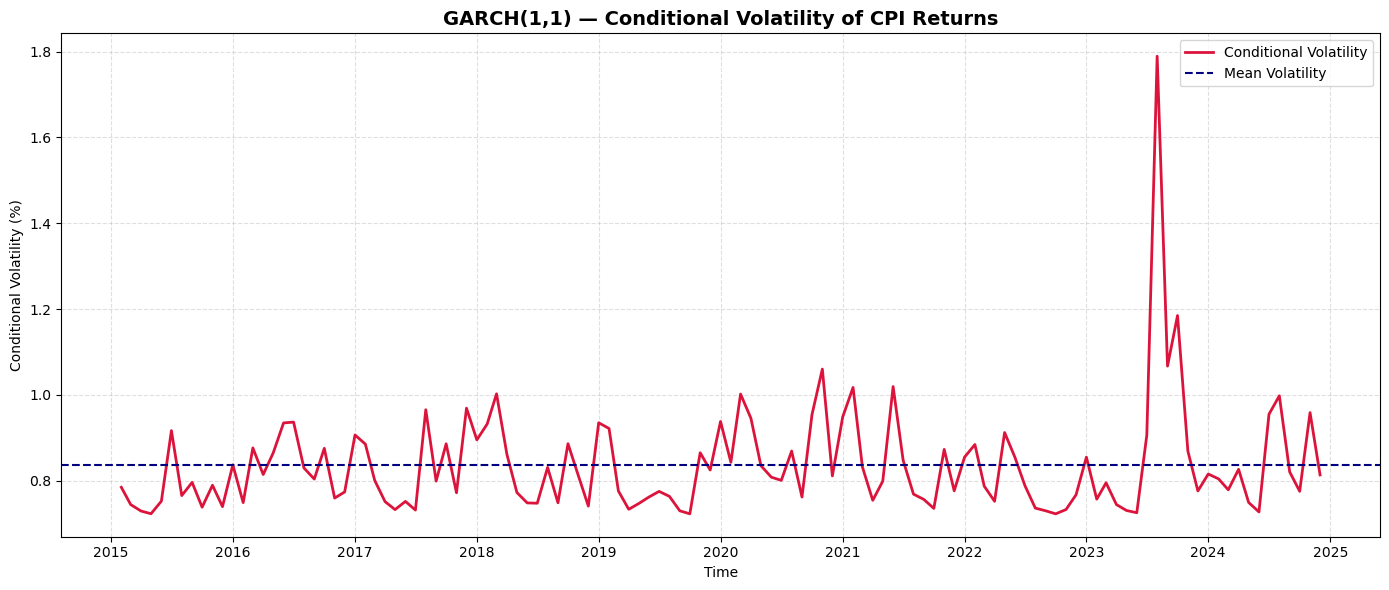

METHOD 4 — GARCH VOLATILITY ANOMALIES
Threshold (97.5th pct) : 1.0606
Anomalies Found        : 3
Anomaly Dates          :
Date
2023-08-01    1.7891
2023-09-01    1.0671
2023-10-01    1.1850
Freq: MS, Name: cond_vol, dtype: float64


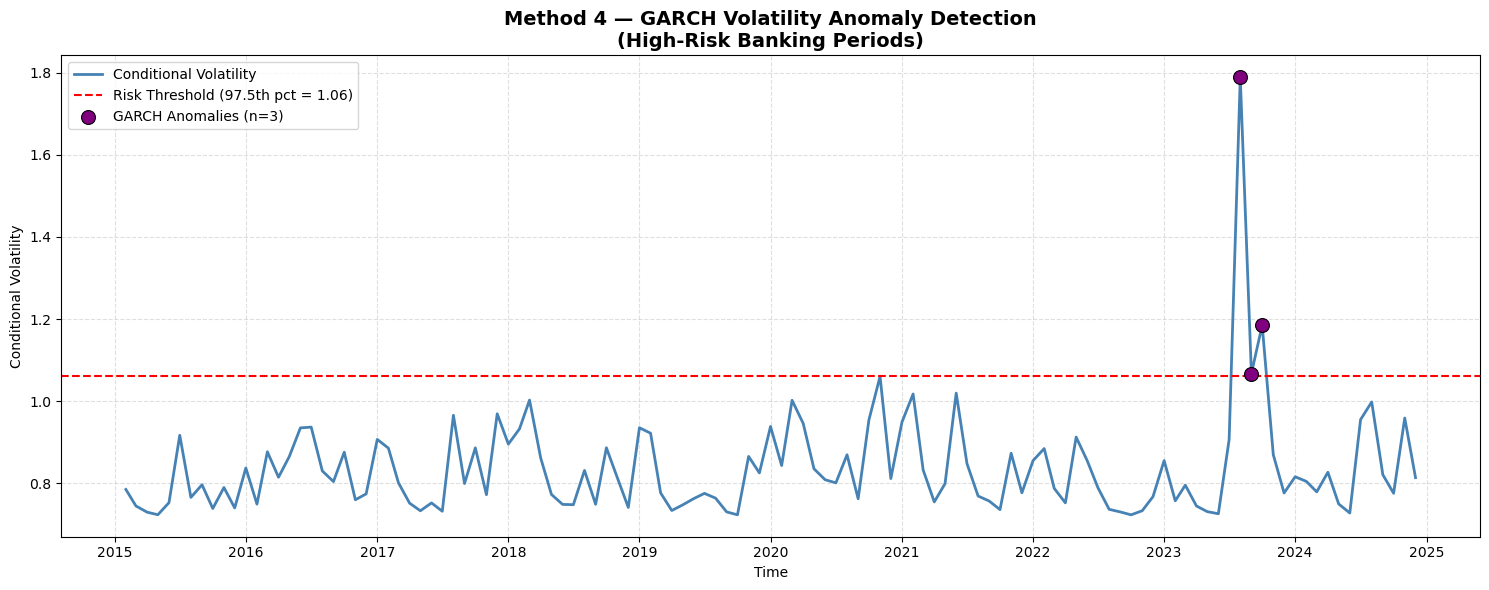


GARCH Parameters:
  alpha[1] (ARCH)      : 0.2234
  beta[1]  (GARCH)     : 0.2050
  Persistence (α+β)    : 0.4284
  → Moderate persistence: shocks dissipate over time

→ GARCH anomaly dates stored for comparison table


In [28]:
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch

# ── ARCH-LM Test
arch_test = het_arch(arima_res)
print("="*48)
print("ARCH-LM TEST")
print("="*48)
print(f"LM Statistic : {arch_test[0]:.4f}")
print(f"p-value      : {arch_test[1]:.6f}")
if arch_test[1] < 0.05:
    print("→ ARCH effect PRESENT → GARCH justified on residuals")
else:
    print("→ Weak ARCH on residuals")
    print("  Applying GARCH to CPI % returns (standard practice)")

# ── CPI % Returns
cpi_ts  = (final_data.groupby(final_data.index)['CPI_value']
           .mean().asfreq('MS').interpolate())
cpi_ret = cpi_ts.pct_change().dropna() * 100
cpi_ret = cpi_ret[cpi_ret != 0]

arch_ret = het_arch(cpi_ret)
print(f"\nARCH test on CPI returns → p-value: {arch_ret[1]:.6f}")
if arch_ret[1] < 0.05:
    print("→ ARCH effect confirmed on CPI returns → GARCH fitted")

# ── Fit GARCH(1,1)
garch_model = arch_model(cpi_ret, vol='Garch',
                          p=1, q=1, dist='normal')
garch_fit   = garch_model.fit(disp='off')
print(garch_fit.summary())

# ── Conditional Volatility
cond_vol = garch_fit.conditional_volatility

plt.figure(figsize=(14, 6))
plt.plot(cond_vol, color='crimson', linewidth=2,
         label='Conditional Volatility')
plt.axhline(cond_vol.mean(), color='navy',
            linestyle='--', label='Mean Volatility')
plt.title("GARCH(1,1) — Conditional Volatility of CPI Returns",
          fontsize=14, fontweight='bold')
plt.xlabel("Time"); plt.ylabel("Conditional Volatility (%)")
plt.legend(); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

# ── Anomaly Detection — 97.5th percentile threshold
vol_threshold  = np.percentile(cond_vol, 97.5)
garch_anoms    = cond_vol[cond_vol > vol_threshold]

print("="*48)
print("METHOD 4 — GARCH VOLATILITY ANOMALIES")
print("="*48)
print(f"Threshold (97.5th pct) : {vol_threshold:.4f}")
print(f"Anomalies Found        : {len(garch_anoms)}")
print(f"Anomaly Dates          :\n{garch_anoms.round(4)}")

plt.figure(figsize=(15, 6))
plt.plot(cond_vol, linewidth=2, color='steelblue',
         label='Conditional Volatility')
plt.axhline(vol_threshold, color='red', linestyle='--',
            label=f'Risk Threshold (97.5th pct = {vol_threshold:.2f})')
plt.scatter(garch_anoms.index, garch_anoms,
            color='purple', s=100, zorder=5,
            edgecolor='black', linewidth=0.8,
            label=f'GARCH Anomalies (n={len(garch_anoms)})')
plt.title("Method 4 — GARCH Volatility Anomaly Detection\n"
          "(High-Risk Banking Periods)",
          fontsize=14, fontweight='bold')
plt.xlabel("Time"); plt.ylabel("Conditional Volatility")
plt.legend(); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

# Model parameters
a1 = garch_fit.params['alpha[1]']
b1 = garch_fit.params['beta[1]']
print(f"\nGARCH Parameters:")
print(f"  alpha[1] (ARCH)      : {a1:.4f}")
print(f"  beta[1]  (GARCH)     : {b1:.4f}")
print(f"  Persistence (α+β)    : {a1+b1:.4f}")
if a1+b1 > 0.9:
    print("  → HIGH persistence: volatility shocks are long-lasting")
    print("    Banking implication: elevated risk windows extend")
else:
    print("  → Moderate persistence: shocks dissipate over time")

# Store results
garch_anomaly_dates = set(garch_anoms.index)
print(f"\n→ GARCH anomaly dates stored for comparison table")

## SECTION 14 | METHOD 5 — ISOLATION FOREST

METHOD 5 — ISOLATION FOREST ANOMALIES
Features used  : ['Inflation_rate', 'CPI_MoM_change', 'CPI_rolling_std_6m', 'CPI_lag_6']
Contamination  : 8%
Total months   : 118
Anomalies      : 10
Anomaly Rate   : 8.47%

Anomaly Dates  :
            banking_risk_index
Date                          
2020-08-01              0.0531
2020-09-01              0.0034
2020-10-01              0.0528
2020-11-01              0.0256
2020-12-01              0.0061
2023-07-01              0.1392
2023-08-01              0.0217
2023-09-01              0.0853
2024-07-01              0.0309
2024-10-01              0.0015


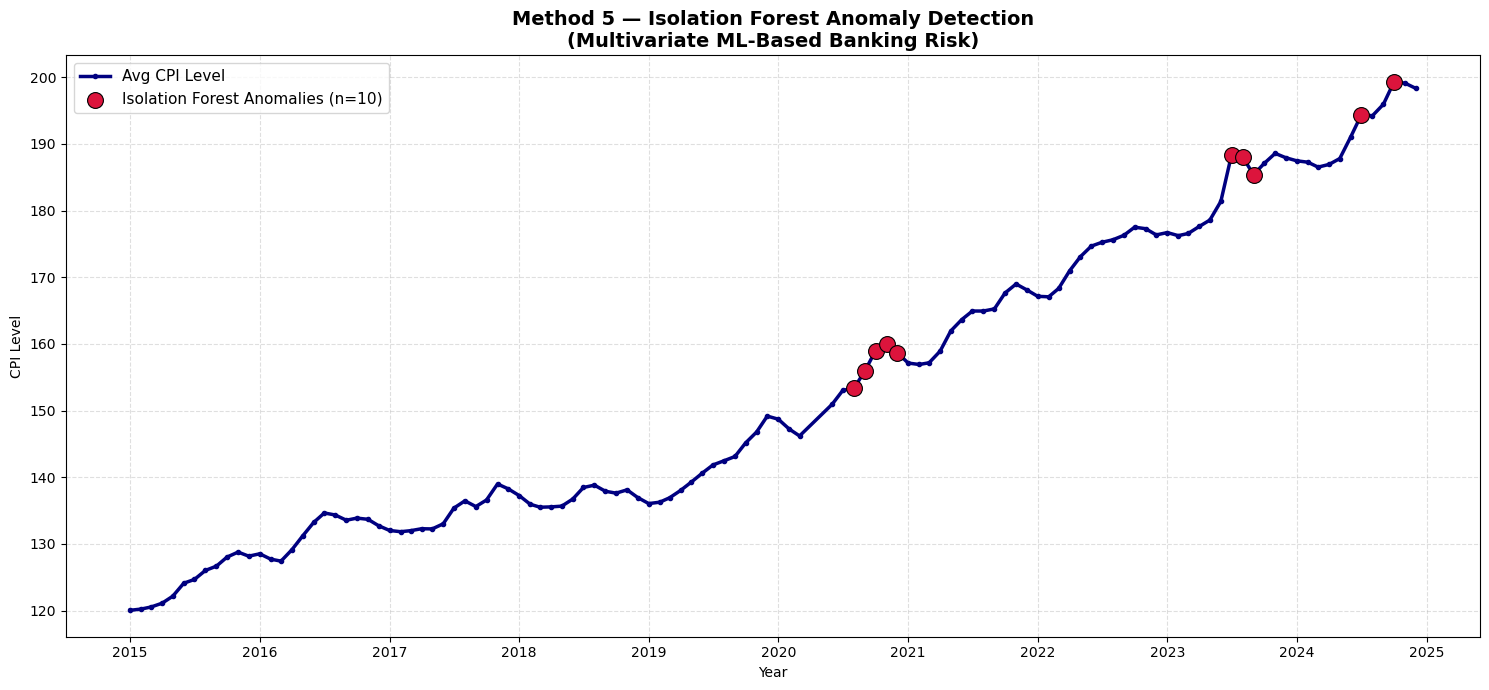

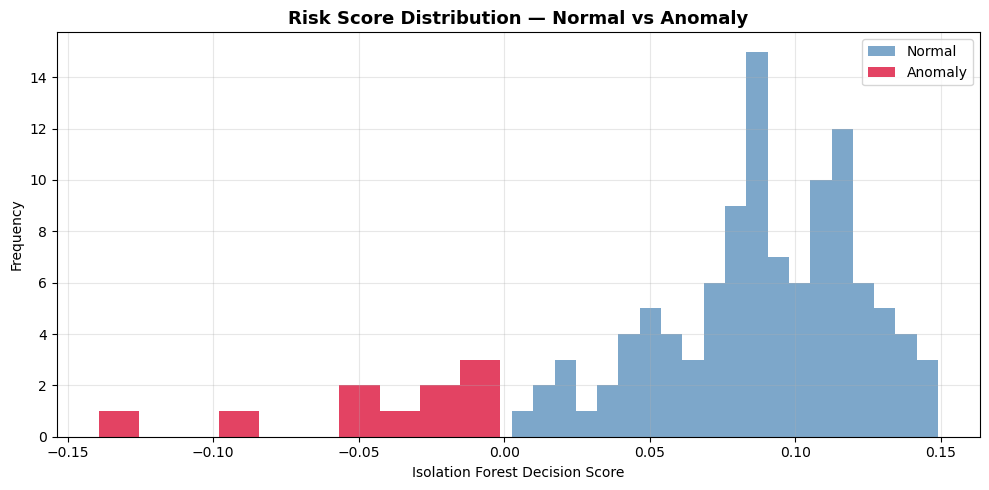

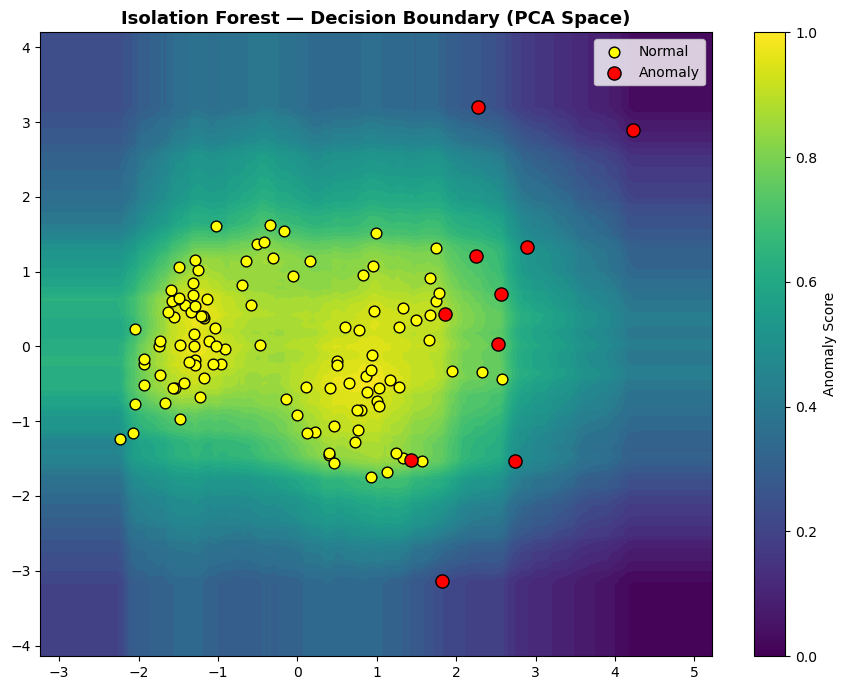


Feature Means — Anomaly vs Normal:
         Inflation_rate  CPI_MoM_change  CPI_rolling_std_6m  CPI_lag_6
anomaly                                                               
-1                7.233           2.195               6.221    163.733
 1                5.060           0.540               3.612    148.110

→ Isolation Forest anomaly dates stored for comparison table


In [29]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA as PCA_viz

# Use SELECTED_FEATURES from Section 8
X_iso = X_anomaly_input.copy()

# Fit Isolation Forest
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.08,
    random_state=42
)
iso_model.fit(X_iso)

macro_data = final_data.groupby(
    final_data.index)[SELECTED_FEATURES].mean().dropna()

X_iso_full  = X_scaled_df.reindex(
    macro_data.index)[SELECTED_FEATURES].dropna()
macro_data  = macro_data.loc[X_iso_full.index]

macro_data['anomaly']            = iso_model.predict(X_iso_full)
macro_data['risk_score']         = iso_model.decision_function(X_iso_full)
macro_data['banking_risk_index'] = -macro_data['risk_score']

iso_anoms = macro_data[macro_data['anomaly'] == -1]

print("="*48)
print("METHOD 5 — ISOLATION FOREST ANOMALIES")
print("="*48)
print(f"Features used  : {SELECTED_FEATURES}")
print(f"Contamination  : 8%")
print(f"Total months   : {len(macro_data)}")
print(f"Anomalies      : {len(iso_anoms)}")
print(f"Anomaly Rate   : {round(len(iso_anoms)/len(macro_data)*100,2)}%")
print(f"\nAnomaly Dates  :")
print(iso_anoms[['banking_risk_index']].round(4))

# ── Plot on CPI
plt.figure(figsize=(15, 7))
plt.plot(macro_data.index,
         final_data.groupby(final_data.index)['CPI_value']
         .mean().reindex(macro_data.index),
         color='navy', linewidth=2.5,
         marker='o', markersize=3, label='Avg CPI Level')
plt.scatter(iso_anoms.index,
            final_data.groupby(final_data.index)['CPI_value']
            .mean().reindex(iso_anoms.index),
            color='crimson', s=130, edgecolor='black',
            linewidth=0.8, zorder=6,
            label=f'Isolation Forest Anomalies (n={len(iso_anoms)})')
plt.title("Method 5 — Isolation Forest Anomaly Detection\n"
          "(Multivariate ML-Based Banking Risk)",
          fontsize=14, fontweight='bold')
plt.xlabel("Year"); plt.ylabel("CPI Level")
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

# ── Risk Score Distribution
plt.figure(figsize=(10, 5))
plt.hist(macro_data[macro_data['anomaly']== 1]['risk_score'],
         bins=20, alpha=0.7, color='steelblue', label='Normal')
plt.hist(macro_data[macro_data['anomaly']==-1]['risk_score'],
         bins=10, alpha=0.8, color='crimson', label='Anomaly')
plt.title("Risk Score Distribution — Normal vs Anomaly",
          fontsize=13, fontweight='bold')
plt.xlabel("Isolation Forest Decision Score")
plt.ylabel("Frequency")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── PCA Decision Boundary
pca2d  = PCA_viz(n_components=2)
X_pca2 = pca2d.fit_transform(X_iso_full)
iso_2d = IsolationForest(n_estimators=300,
                          contamination=0.08,
                          random_state=42).fit(X_pca2)

xx, yy = np.meshgrid(
    np.linspace(X_pca2[:,0].min()-1,
                X_pca2[:,0].max()+1, 200),
    np.linspace(X_pca2[:,1].min()-1,
                X_pca2[:,1].max()+1, 200)
)
Z = iso_2d.decision_function(
    np.c_[xx.ravel(), yy.ravel()]
).reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, Z, levels=50, cmap='viridis')
plt.scatter(X_pca2[macro_data['anomaly']== 1, 0],
            X_pca2[macro_data['anomaly']== 1, 1],
            c='yellow', edgecolor='k',
            label='Normal', s=60)
plt.scatter(X_pca2[macro_data['anomaly']==-1, 0],
            X_pca2[macro_data['anomaly']==-1, 1],
            c='red', edgecolor='k',
            label='Anomaly', s=90)
plt.title("Isolation Forest — Decision Boundary (PCA Space)",
          fontsize=13, fontweight='bold')
plt.colorbar(label='Anomaly Score')
plt.legend(); plt.tight_layout(); plt.show()

# ── Feature Contribution (mean values: anomaly vs normal)
print("\nFeature Means — Anomaly vs Normal:")
print(macro_data.groupby('anomaly')[SELECTED_FEATURES].mean().round(3))

# Store results
iso_anomaly_dates = set(iso_anoms.index)
print(f"\n→ Isolation Forest anomaly dates stored for comparison table")

## SECTION 15 | ANOMALY COMPARISON TABLE

ANOMALY COMPARISON TABLE — ALL 5 METHODS
            Inflation  Z_Score  ARIMA  SARIMA  GARCH  Isolation_Forest  Methods_Count   Risk_Level
Date                                                                                              
2015-01-01      5.430        0      1       1      0                 0              2  MEDIUM RISK
2016-01-01      7.050        0      0       1      0                 0              1     LOW RISK
2017-01-01      3.356        0      0       1      0                 0              1     LOW RISK
2018-11-01     -0.266        1      0       0      0                 0              1     LOW RISK
2018-12-01     -0.683        1      0       0      0                 0              1     LOW RISK
2019-01-01     -0.729        1      0       0      0                 0              1     LOW RISK
2019-02-01      0.298        1      0       0      0                 0              1     LOW RISK
2019-12-01      9.082        0      1       1      0                

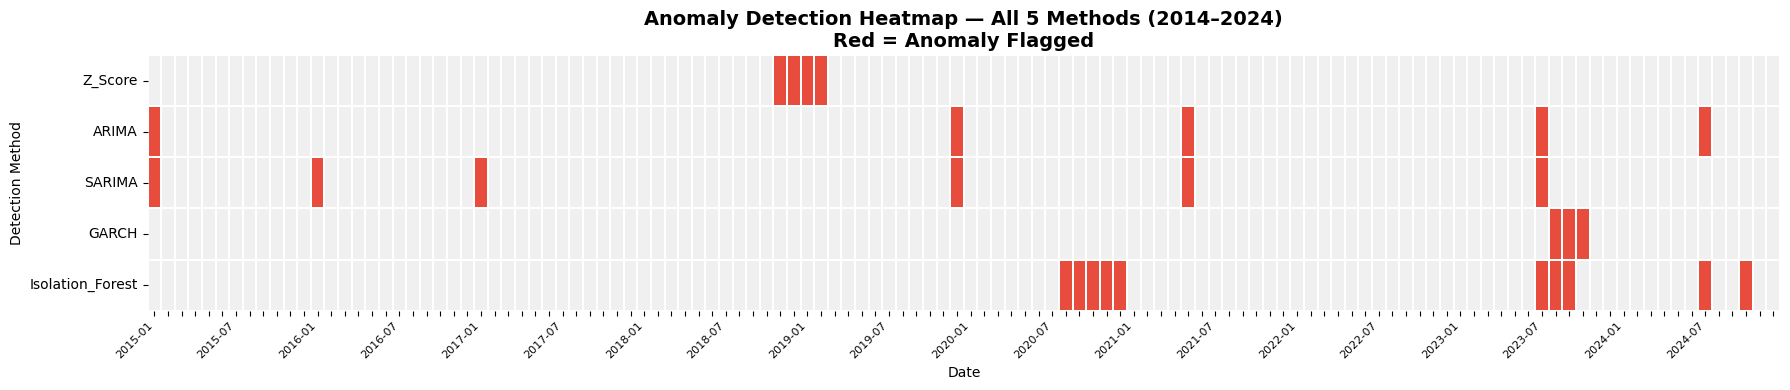

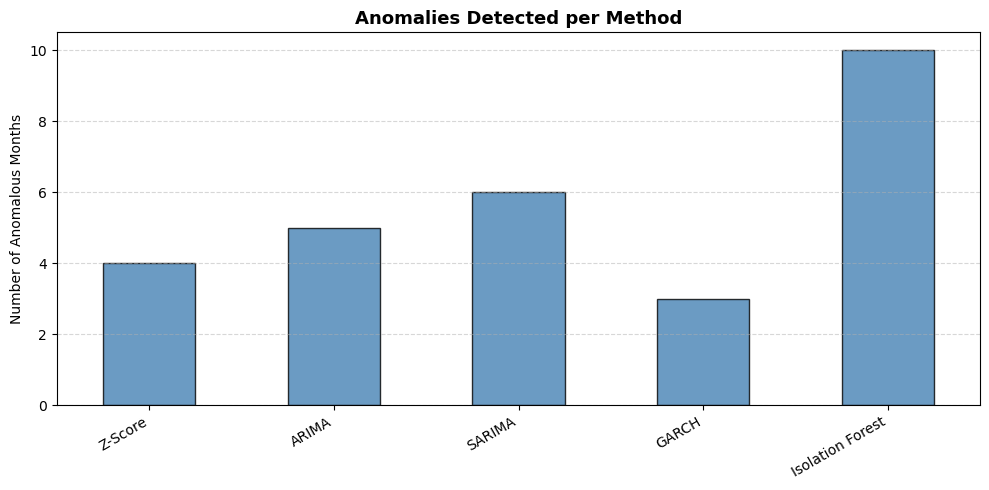


→ comparison_df ready for Phase 3 — Risk Assessment
→ macro_data['banking_risk_index'] ready for XGBoost

Phase 4 Complete ✅


In [32]:
# Build unified monthly index
all_dates = sorted(set(ts_ms.index)
                   .union(macro_data.index))

comparison_df = pd.DataFrame(index=pd.DatetimeIndex(all_dates))
comparison_df.index.name = 'Date'

# Flag each method (1 = anomaly, 0 = normal)
comparison_df['Z_Score']         = comparison_df.index.isin(
    zscore_anomaly_dates).astype(int)
comparison_df['ARIMA']           = comparison_df.index.isin(
    arima_anomaly_dates).astype(int)
comparison_df['SARIMA']          = comparison_df.index.isin(
    sarima_anomaly_dates).astype(int)
comparison_df['GARCH']           = comparison_df.index.isin(
    garch_anomaly_dates).astype(int)
comparison_df['Isolation_Forest']= comparison_df.index.isin(
    iso_anomaly_dates).astype(int)

# Count how many methods flagged each month
comparison_df['Methods_Count'] = comparison_df[[
    'Z_Score','ARIMA','SARIMA','GARCH','Isolation_Forest'
]].sum(axis=1)

# Risk classification
def classify_risk(n):
    if n >= 3: return 'HIGH RISK'
    elif n == 2: return 'MEDIUM RISK'
    elif n == 1: return 'LOW RISK'
    else: return 'Normal'

comparison_df['Risk_Level'] = comparison_df[
    'Methods_Count'].apply(classify_risk)

# Show only flagged months
flagged = comparison_df[comparison_df['Methods_Count'] > 0].copy()
flagged['Inflation'] = ts_ms.reindex(flagged.index).round(3)

print("="*70)
print("ANOMALY COMPARISON TABLE — ALL 5 METHODS")
print("="*70)
print(flagged[[
    'Inflation','Z_Score','ARIMA','SARIMA',
    'GARCH','Isolation_Forest','Methods_Count','Risk_Level'
]].to_string())

# Summary counts
print("\n" + "="*50)
print("DETECTION SUMMARY BY METHOD")
print("="*50)
method_counts = {
    'Z-Score'         : len(zscore_anomaly_dates),
    'ARIMA'           : len(arima_anomaly_dates),
    'SARIMA'          : len(sarima_anomaly_dates),
    'GARCH'           : len(garch_anomaly_dates),
    'Isolation Forest': len(iso_anomaly_dates)
}
for m, c in method_counts.items():
    print(f"  {m:20s}: {c} anomalies")

confirmed_high = comparison_df[
    comparison_df['Risk_Level'] == 'HIGH RISK']
print(f"\nConfirmed HIGH RISK months (3+ methods): "
      f"{len(confirmed_high)}")
print(confirmed_high.index.strftime('%Y-%m').tolist())

# ── Heatmap — all methods across time
pivot = comparison_df[[
    'Z_Score','ARIMA','SARIMA','GARCH','Isolation_Forest'
]].T

plt.figure(figsize=(18, 4))
sns.heatmap(pivot,
            cmap=['#f0f0f0','#e74c3c'],
            linewidths=0.3, linecolor='white',
            cbar=False,
            xticklabels=[
                d.strftime('%Y-%m')
                if i % 6 == 0 else ''
                for i, d in enumerate(comparison_df.index)
            ])
plt.title("Anomaly Detection Heatmap — All 5 Methods (2014–2024)\n"
          "Red = Anomaly Flagged",
          fontsize=14, fontweight='bold')
plt.ylabel("Detection Method")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout(); plt.show()

# ── Bar chart — method counts
plt.figure(figsize=(10, 5))
pd.Series(method_counts).plot(kind='bar', color='steelblue',
                               edgecolor='black', alpha=0.8)
plt.title("Anomalies Detected per Method",
          fontsize=13, fontweight='bold')
plt.ylabel("Number of Anomalous Months")
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# Store for Phase 3
print("\n→ comparison_df ready for Phase 3 — Risk Assessment")
print("→ macro_data['banking_risk_index'] ready for XGBoost")
print("\nPhase 4 Complete ✅")


# ─────────────────────────────────────────────────────────────
# PHASE 5 | Risk Assesment
# ─────────────────────────────────────────────────────────────

## SECTION 16 | COMBINED BANKING RISK INDEX (CBRI)

COMBINED BANKING RISK INDEX (CBRI)
Weights Applied:
  Z-Score          : 0.1
  ARIMA            : 0.15
  SARIMA           : 0.15
  GARCH            : 0.35 (highest — volatility risk)
  Isolation Forest : 0.25

CBRI Statistics:
count    120.0000
mean       0.1146
std        0.1001
min        0.0023
25%        0.0598
50%        0.0808
75%        0.1290
max        0.6102
Name: CBRI, dtype: float64


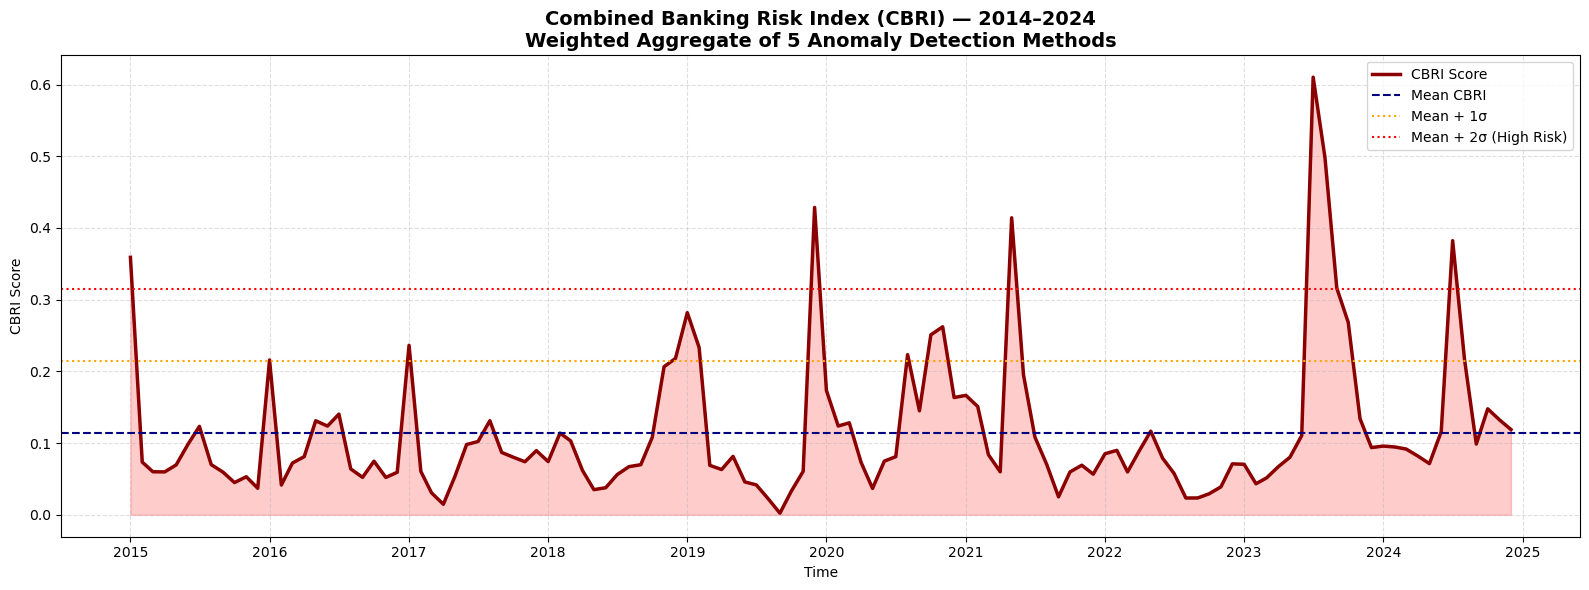


→ cbri_df['CBRI'] ready for risk classification


In [33]:
# ── Step 1: Build base dataframe from comparison_df
cbri_df = comparison_df.copy()

# ── Step 2: Attach normalised GARCH volatility as continuous signal
# Normalise conditional volatility to 0–1 scale
cond_vol_reindexed = cond_vol.reindex(cbri_df.index)
garch_norm = (
    (cond_vol_reindexed - cond_vol_reindexed.min()) /
    (cond_vol_reindexed.max() - cond_vol_reindexed.min())
).fillna(0)

cbri_df['GARCH_vol_norm'] = garch_norm

# ── Step 3: Attach Isolation Forest risk score (normalised)
iso_risk = macro_data['banking_risk_index'].reindex(cbri_df.index)
iso_norm = (
    (iso_risk - iso_risk.min()) /
    (iso_risk.max() - iso_risk.min())
).fillna(0)

cbri_df['ISO_risk_norm'] = iso_norm

# ── Step 4: Weighted CBRI formula
# Weights reflect each method's sensitivity to banking risk:
#   Z-Score         → 0.10 (simple baseline, low specificity)
#   ARIMA           → 0.15 (captures level shocks)
#   SARIMA          → 0.15 (captures seasonal shocks)
#   GARCH           → 0.35 (volatility = core banking risk)
#   Isolation Forest→ 0.25 (multivariate ML signal)

W_ZSCORE = 0.10
W_ARIMA  = 0.15
W_SARIMA = 0.15
W_GARCH  = 0.35
W_ISO    = 0.25

cbri_df['CBRI'] = (
    W_ZSCORE * cbri_df['Z_Score'] +
    W_ARIMA  * cbri_df['ARIMA'] +
    W_SARIMA * cbri_df['SARIMA'] +
    W_GARCH  * cbri_df['GARCH_vol_norm'] +
    W_ISO    * cbri_df['ISO_risk_norm']
)

print("="*55)
print("COMBINED BANKING RISK INDEX (CBRI)")
print("="*55)
print(f"Weights Applied:")
print(f"  Z-Score          : {W_ZSCORE}")
print(f"  ARIMA            : {W_ARIMA}")
print(f"  SARIMA           : {W_SARIMA}")
print(f"  GARCH            : {W_GARCH} (highest — volatility risk)")
print(f"  Isolation Forest : {W_ISO}")
print(f"\nCBRI Statistics:")
print(cbri_df['CBRI'].describe().round(4))

# ── Plot CBRI over time
plt.figure(figsize=(16, 6))
plt.plot(cbri_df.index, cbri_df['CBRI'],
         linewidth=2.5, color='darkred', label='CBRI Score')
plt.fill_between(cbri_df.index, cbri_df['CBRI'],
                 alpha=0.2, color='red')
plt.axhline(cbri_df['CBRI'].mean(),
            color='navy', linestyle='--',
            linewidth=1.5, label='Mean CBRI')
plt.axhline(cbri_df['CBRI'].mean() + cbri_df['CBRI'].std(),
            color='orange', linestyle=':',
            linewidth=1.5, label='Mean + 1σ')
plt.axhline(cbri_df['CBRI'].mean() + 2*cbri_df['CBRI'].std(),
            color='red', linestyle=':',
            linewidth=1.5, label='Mean + 2σ (High Risk)')

plt.title("Combined Banking Risk Index (CBRI) — 2014–2024\n"
          "Weighted Aggregate of 5 Anomaly Detection Methods",
          fontsize=14, fontweight='bold')
plt.xlabel("Time")
plt.ylabel("CBRI Score")
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Store CBRI for next sections
print("\n→ cbri_df['CBRI'] ready for risk classification")

## SECTION 17 | RISK PERIOD CLASSIFICATION

CBRI RISK THRESHOLDS
  Normal   : CBRI < 0.1146
  Low Risk : 0.1146 ≤ CBRI < 0.1646
  Medium   : 0.1646 ≤ CBRI < 0.2146
  High     : 0.2146 ≤ CBRI < 0.2647
  Critical : CBRI ≥ 0.2647

Risk Tier Distribution:
  Normal    :  83 months (69.2%)
  Low       :  16 months (13.3%)
  Medium    :   4 months (3.3%)
  High      :   8 months (6.7%)
  Critical  :   9 months (7.5%)


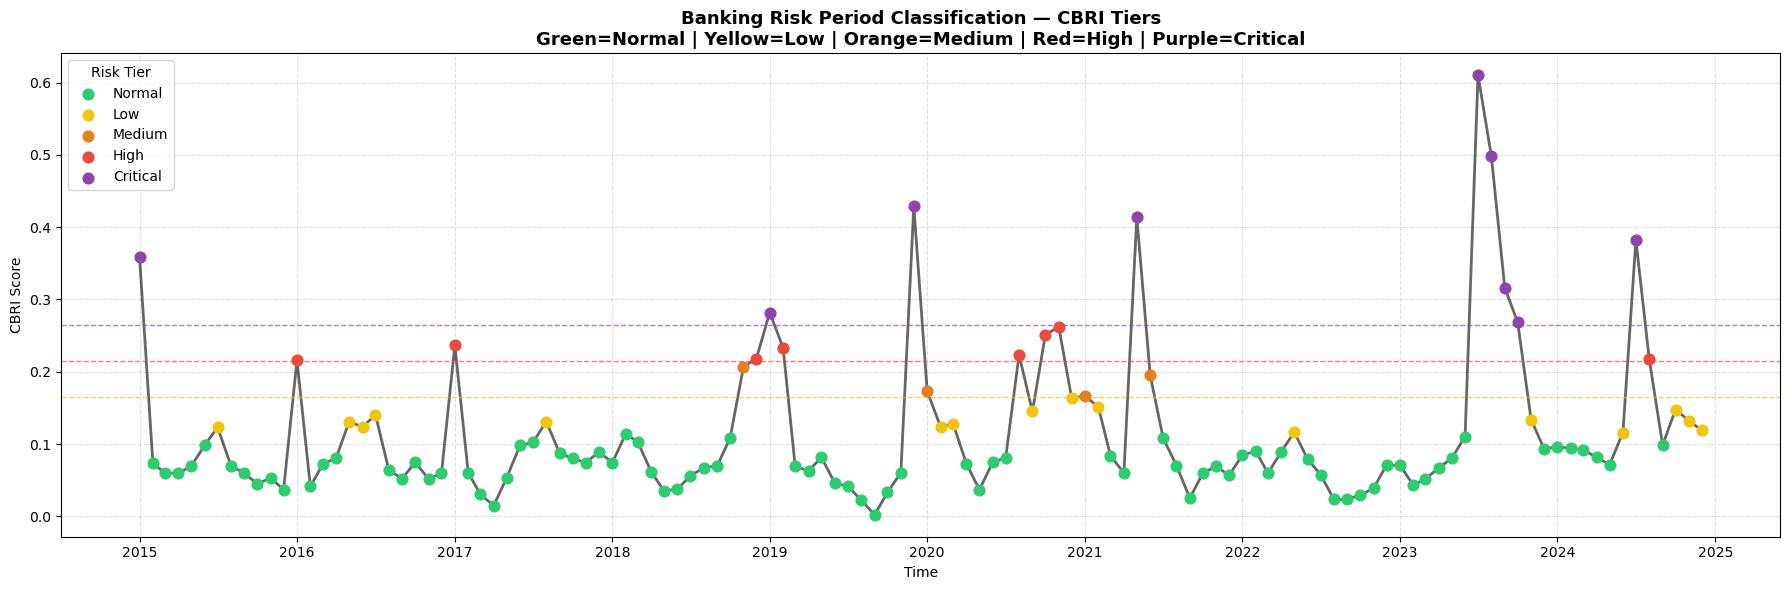

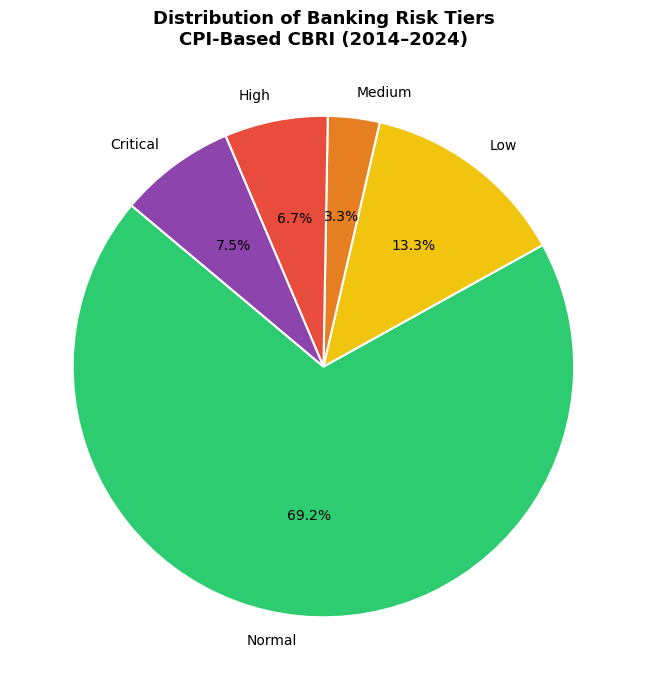


HIGH/CRITICAL RISK PERIODS — BANKING SECTOR INTERPRETATION

  2015 — ['Jan']
  Tier    : ['Critical']
  Context : Global commodity price collapse — deflationary pressure

  2016 — ['Jan']
  Tier    : ['High']
  Context : Demonetisation shock — liquidity disruption in banking

  2017 — ['Jan']
  Tier    : ['High']
  Context : GST implementation — supply chain price distortions

  2018 — ['Dec']
  Tier    : ['High']
  Context : Macroeconomic stress period

  2019 — ['Jan', 'Feb', 'Dec']
  Tier    : ['Critical', 'High', 'Critical']
  Context : NBFC crisis — credit risk elevated in banking sector

  2020 — ['Aug', 'Oct', 'Nov']
  Tier    : ['High', 'High', 'High']
  Context : COVID-19 pandemic — demand collapse, NPA risk surge

  2021 — ['May']
  Tier    : ['Critical']
  Context : Post-COVID supply shock — input cost inflation surge

  2023 — ['Jul', 'Aug', 'Sep', 'Oct']
  Tier    : ['Critical', 'Critical', 'Critical', 'Critical']
  Context : Monetary tightening cycle — rate risk for bank

In [34]:
# ── Step 1: Define CBRI thresholds
cbri_mean = cbri_df['CBRI'].mean()
cbri_std  = cbri_df['CBRI'].std()

T_LOW      = cbri_mean                    # above mean
T_MEDIUM   = cbri_mean + 0.5*cbri_std     # moderate elevation
T_HIGH     = cbri_mean + 1.0*cbri_std     # clearly elevated
T_CRITICAL = cbri_mean + 1.5*cbri_std     # extreme risk

print("="*50)
print("CBRI RISK THRESHOLDS")
print("="*50)
print(f"  Normal   : CBRI < {T_LOW:.4f}")
print(f"  Low Risk : {T_LOW:.4f} ≤ CBRI < {T_MEDIUM:.4f}")
print(f"  Medium   : {T_MEDIUM:.4f} ≤ CBRI < {T_HIGH:.4f}")
print(f"  High     : {T_HIGH:.4f} ≤ CBRI < {T_CRITICAL:.4f}")
print(f"  Critical : CBRI ≥ {T_CRITICAL:.4f}")

# ── Step 2: Classify each month
def classify_cbri(score):
    if score >= T_CRITICAL: return 'Critical'
    elif score >= T_HIGH:   return 'High'
    elif score >= T_MEDIUM: return 'Medium'
    elif score >= T_LOW:    return 'Low'
    else:                   return 'Normal'

cbri_df['Risk_Tier'] = cbri_df['CBRI'].apply(classify_cbri)

# Distribution of risk tiers
tier_counts = cbri_df['Risk_Tier'].value_counts()
tier_order  = ['Normal','Low','Medium','High','Critical']
tier_counts = tier_counts.reindex(
    [t for t in tier_order if t in tier_counts.index]
)

print("\nRisk Tier Distribution:")
for tier, count in tier_counts.items():
    pct = round(count / len(cbri_df) * 100, 1)
    print(f"  {tier:10s}: {count:3d} months ({pct}%)")

# ── Step 3: Risk tier colour-coded timeline
tier_colors = {
    'Normal'  : '#2ecc71',
    'Low'     : '#f1c40f',
    'Medium'  : '#e67e22',
    'High'    : '#e74c3c',
    'Critical': '#8e44ad'
}

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(cbri_df.index, cbri_df['CBRI'],
        linewidth=2, color='black', alpha=0.6, zorder=2)

for tier in tier_order:
    mask = cbri_df['Risk_Tier'] == tier
    ax.scatter(
        cbri_df.index[mask],
        cbri_df['CBRI'][mask],
        color=tier_colors.get(tier, 'grey'),
        s=60, zorder=3, label=tier
    )

# Threshold lines
ax.axhline(T_MEDIUM,   color='#f1c40f', linestyle='--',
           alpha=0.7, linewidth=1)
ax.axhline(T_HIGH,     color='#e74c3c', linestyle='--',
           alpha=0.7, linewidth=1)
ax.axhline(T_CRITICAL, color='#8e44ad', linestyle='--',
           alpha=0.7, linewidth=1)

ax.set_title("Banking Risk Period Classification — CBRI Tiers\n"
             "Green=Normal | Yellow=Low | Orange=Medium | "
             "Red=High | Purple=Critical",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Time")
ax.set_ylabel("CBRI Score")
ax.legend(title="Risk Tier", loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Step 4: Pie chart of risk distribution
plt.figure(figsize=(7, 7))
colors_pie = [tier_colors[t] for t in tier_counts.index]
plt.pie(
    tier_counts.values,
    labels=tier_counts.index,
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title("Distribution of Banking Risk Tiers\n"
          "CPI-Based CBRI (2014–2024)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Step 5: Real-world event mapping
print("\n" + "="*60)
print("HIGH/CRITICAL RISK PERIODS — BANKING SECTOR INTERPRETATION")
print("="*60)

event_map = {
    2015: "Global commodity price collapse — deflationary pressure",
    2016: "Demonetisation shock — liquidity disruption in banking",
    2017: "GST implementation — supply chain price distortions",
    2019: "NBFC crisis — credit risk elevated in banking sector",
    2020: "COVID-19 pandemic — demand collapse, NPA risk surge",
    2021: "Post-COVID supply shock — input cost inflation surge",
    2022: "Global commodity & energy shock — fuel/food inflation",
    2023: "Monetary tightening cycle — rate risk for bank portfolios",
    2024: "Persistent core inflation — margin pressure on banks"
}

critical_high = cbri_df[
    cbri_df['Risk_Tier'].isin(['High','Critical'])
].copy()
critical_high['Year'] = critical_high.index.year
critical_high['Inflation'] = ts_ms.reindex(
    critical_high.index).round(3)

for year, grp in critical_high.groupby('Year'):
    months  = grp.index.strftime('%b').tolist()
    tiers   = grp['Risk_Tier'].tolist()
    context = event_map.get(year, "Macroeconomic stress period")
    print(f"\n  {year} — {months}")
    print(f"  Tier    : {tiers}")
    print(f"  Context : {context}")

## SECTION 18 | GARCH VOLATILITY RISK FORECAST

GARCH(1,1) — 12-MONTH VOLATILITY FORECAST
2025-01-01    0.8323
2025-02-01    0.8426
2025-03-01    0.8470
2025-04-01    0.8489
2025-05-01    0.8497
2025-06-01    0.8500
2025-07-01    0.8502
2025-08-01    0.8502
2025-09-01    0.8502
2025-10-01    0.8503
2025-11-01    0.8503
2025-12-01    0.8503
Freq: MS


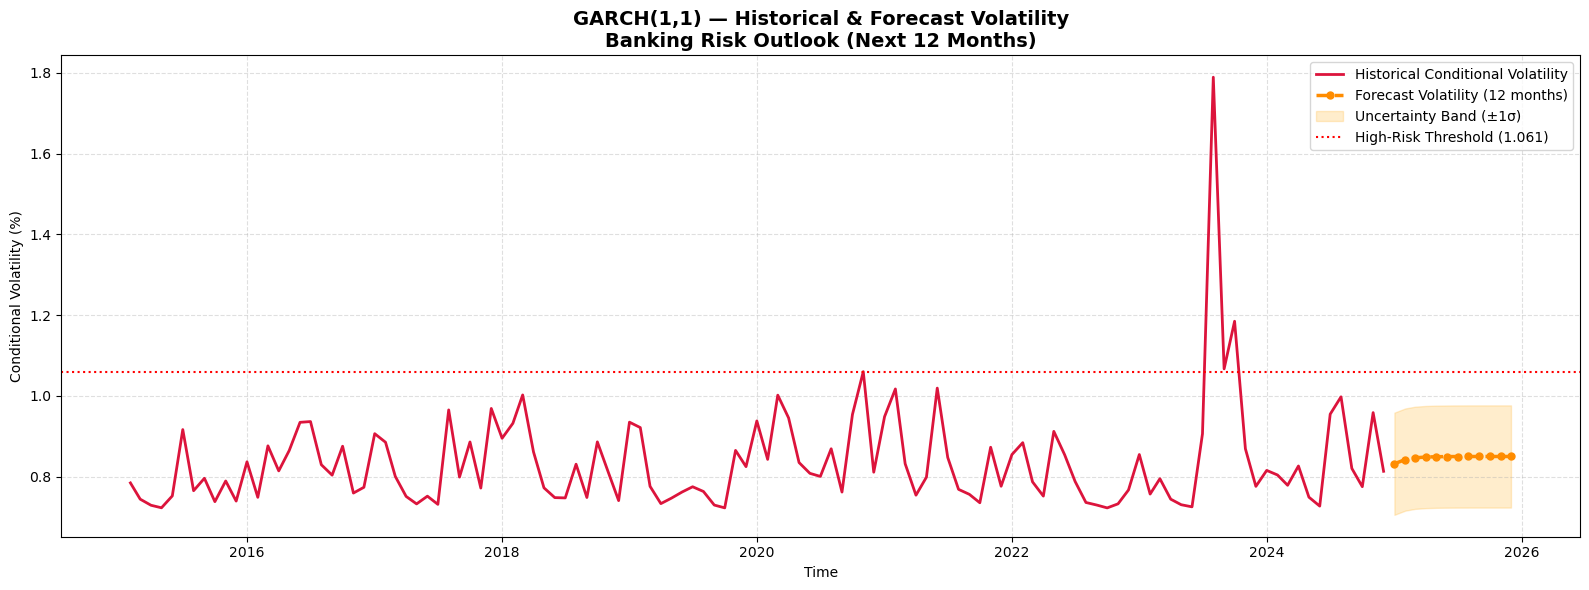


FORECAST RISK OUTLOOK — MONTH BY MONTH
  Jan 2025 → Volatility: 0.8323  |  ~ ELEVATED
  Feb 2025 → Volatility: 0.8426  |  ~ ELEVATED
  Mar 2025 → Volatility: 0.8470  |  ~ ELEVATED
  Apr 2025 → Volatility: 0.8489  |  ~ ELEVATED
  May 2025 → Volatility: 0.8497  |  ~ ELEVATED
  Jun 2025 → Volatility: 0.8500  |  ~ ELEVATED
  Jul 2025 → Volatility: 0.8502  |  ~ ELEVATED
  Aug 2025 → Volatility: 0.8502  |  ~ ELEVATED
  Sep 2025 → Volatility: 0.8502  |  ~ ELEVATED
  Oct 2025 → Volatility: 0.8503  |  ~ ELEVATED
  Nov 2025 → Volatility: 0.8503  |  ~ ELEVATED
  Dec 2025 → Volatility: 0.8503  |  ~ ELEVATED

GARCH PERSISTENCE ANALYSIS
  alpha[1] (ARCH effect)   : 0.2234
  beta[1]  (GARCH effect)  : 0.2050
  Persistence (α + β)      : 0.4284

  → MODERATE persistence
    Shocks dissipate relatively quickly
    Banking implication: Short-term risk monitoring
    is sufficient for most CPI-linked exposures


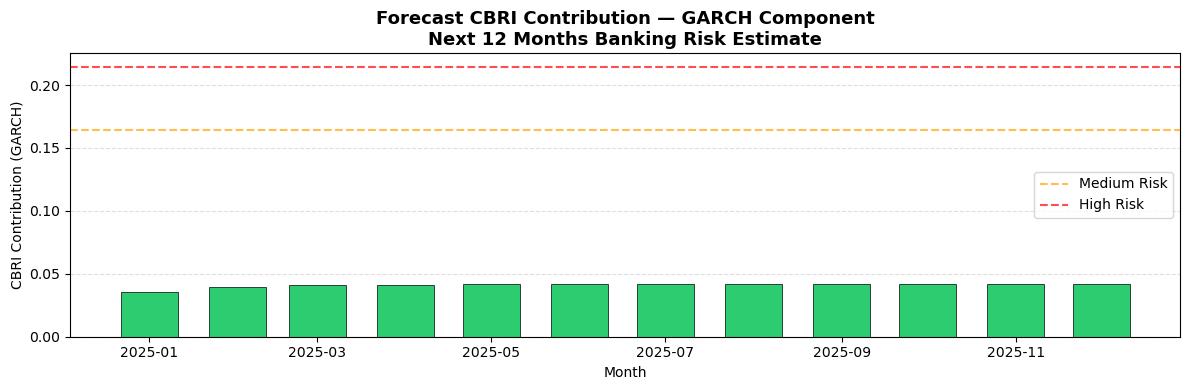


✅ Phase 3 Complete
PHASE 3 SUMMARY — RISK ASSESSMENT OUTPUTS
  Section 16 → CBRI constructed (weighted 5-method index)
  Section 17 → Risk tiers classified + real-world events
  Section 18 → 12-month volatility forecast + risk outlook

Next → Phase 4: XGBoost forecasting using CBRI as feature


In [35]:
# ── Step 1: 12-Month Volatility Forecast
garch_fc  = garch_fit.forecast(horizon=12)
fc_var    = garch_fc.variance.iloc[-1]
fc_vol    = np.sqrt(fc_var.values)

# Forecast index — 12 months after last data point
last_date   = cond_vol.index[-1]
fc_index    = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12, freq='MS'
)

fc_series = pd.Series(fc_vol, index=fc_index)

print("="*52)
print("GARCH(1,1) — 12-MONTH VOLATILITY FORECAST")
print("="*52)
print(fc_series.round(4).to_string())

# ── Step 2: Plot historical + forecast volatility
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(cond_vol.index, cond_vol,
        color='crimson', linewidth=2,
        label='Historical Conditional Volatility')
ax.plot(fc_series.index, fc_series,
        color='darkorange', linewidth=2.5,
        linestyle='--', marker='o', markersize=5,
        label='Forecast Volatility (12 months)')

# Confidence band around forecast (±1 std of historical vol)
hist_std = cond_vol.std()
ax.fill_between(
    fc_series.index,
    fc_series - hist_std,
    fc_series + hist_std,
    alpha=0.2, color='orange',
    label='Uncertainty Band (±1σ)'
)

# Risk threshold line
ax.axhline(vol_threshold,
           color='red', linestyle=':',
           linewidth=1.5,
           label=f'High-Risk Threshold ({vol_threshold:.3f})')

ax.set_title("GARCH(1,1) — Historical & Forecast Volatility\n"
             "Banking Risk Outlook (Next 12 Months)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Time")
ax.set_ylabel("Conditional Volatility (%)")
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Step 3: Classify forecast months into risk tiers
print("\n" + "="*52)
print("FORECAST RISK OUTLOOK — MONTH BY MONTH")
print("="*52)

for date, vol in fc_series.items():
    if vol >= vol_threshold:
        tier = "⚠ HIGH RISK"
    elif vol >= vol_threshold * 0.75:
        tier = "~ ELEVATED"
    else:
        tier = "✓ NORMAL"
    print(f"  {date.strftime('%b %Y')} → "
          f"Volatility: {vol:.4f}  |  {tier}")

# ── Step 4: GARCH persistence interpretation
a1 = garch_fit.params['alpha[1]']
b1 = garch_fit.params['beta[1]']
persistence = a1 + b1

print("\n" + "="*52)
print("GARCH PERSISTENCE ANALYSIS")
print("="*52)
print(f"  alpha[1] (ARCH effect)   : {a1:.4f}")
print(f"  beta[1]  (GARCH effect)  : {b1:.4f}")
print(f"  Persistence (α + β)      : {persistence:.4f}")

if persistence > 0.95:
    print("\n  → VERY HIGH persistence")
    print("    Volatility shocks take many months to dissipate")
    print("    Banking implication: Risk windows are prolonged —")
    print("    banks should maintain elevated capital buffers")
elif persistence > 0.85:
    print("\n  → HIGH persistence")
    print("    Volatility elevated for several months post-shock")
    print("    Banking implication: Risk management requires")
    print("    medium-term horizon adjustments")
else:
    print("\n  → MODERATE persistence")
    print("    Shocks dissipate relatively quickly")
    print("    Banking implication: Short-term risk monitoring")
    print("    is sufficient for most CPI-linked exposures")

# ── Step 5: Attach forecast CBRI estimate
fc_cbri_estimate = W_GARCH * (
    (fc_series - cond_vol.min()) /
    (cond_vol.max() - cond_vol.min())
)

plt.figure(figsize=(12, 4))
plt.bar(fc_series.index, fc_cbri_estimate.values,
        color=['#e74c3c' if v > T_HIGH else '#f1c40f'
               if v > T_MEDIUM else '#2ecc71'
               for v in fc_cbri_estimate.values],
        edgecolor='black', linewidth=0.5,
        width=20)
plt.title("Forecast CBRI Contribution — GARCH Component\n"
          "Next 12 Months Banking Risk Estimate",
          fontsize=13, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("CBRI Contribution (GARCH)")
plt.axhline(T_MEDIUM, color='orange',
            linestyle='--', alpha=0.7, label='Medium Risk')
plt.axhline(T_HIGH, color='red',
            linestyle='--', alpha=0.7, label='High Risk')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# PHASE 6 | XGBoost Forecast
# ─────────────────────────────────────────────────────────────

## SECTION 19 | XGBoost — WITH vs WITHOUT CBRI

Forecast dataset shape: (117, 7)
Dtypes:
 Inflation_rate        float64
CPI_MoM_change        float64
CPI_rolling_std_6m    float64
CPI_lag_6             float64
CBRI                  float64
Risk_Tier_num           int64
target                float64
dtype: object

Train size : 93 months
Test size  : 24 months
X_base_train dtype : float64, shape: (93, 5)
X_cbri_train dtype : float64, shape: (93, 7)

MODEL A — XGBoost WITHOUT CBRI (Baseline)
  MAE  : 0.7378
  RMSE : 1.0443
  MAPE : 14.37%

MODEL B — XGBoost WITH CBRI (Enhanced)
  MAE  : 0.7771
  RMSE : 1.0630
  MAPE : 15.04%

CBRI IMPACT ON FORECAST ACCURACY
  MAE  improvement  : -5.32%
  RMSE improvement  : -1.79%
  MAPE improvement  : -4.68%

  ⚠ CBRI did not improve accuracy on this split
    → Consider tuning contamination rate in
      Isolation Forest (Section 14)


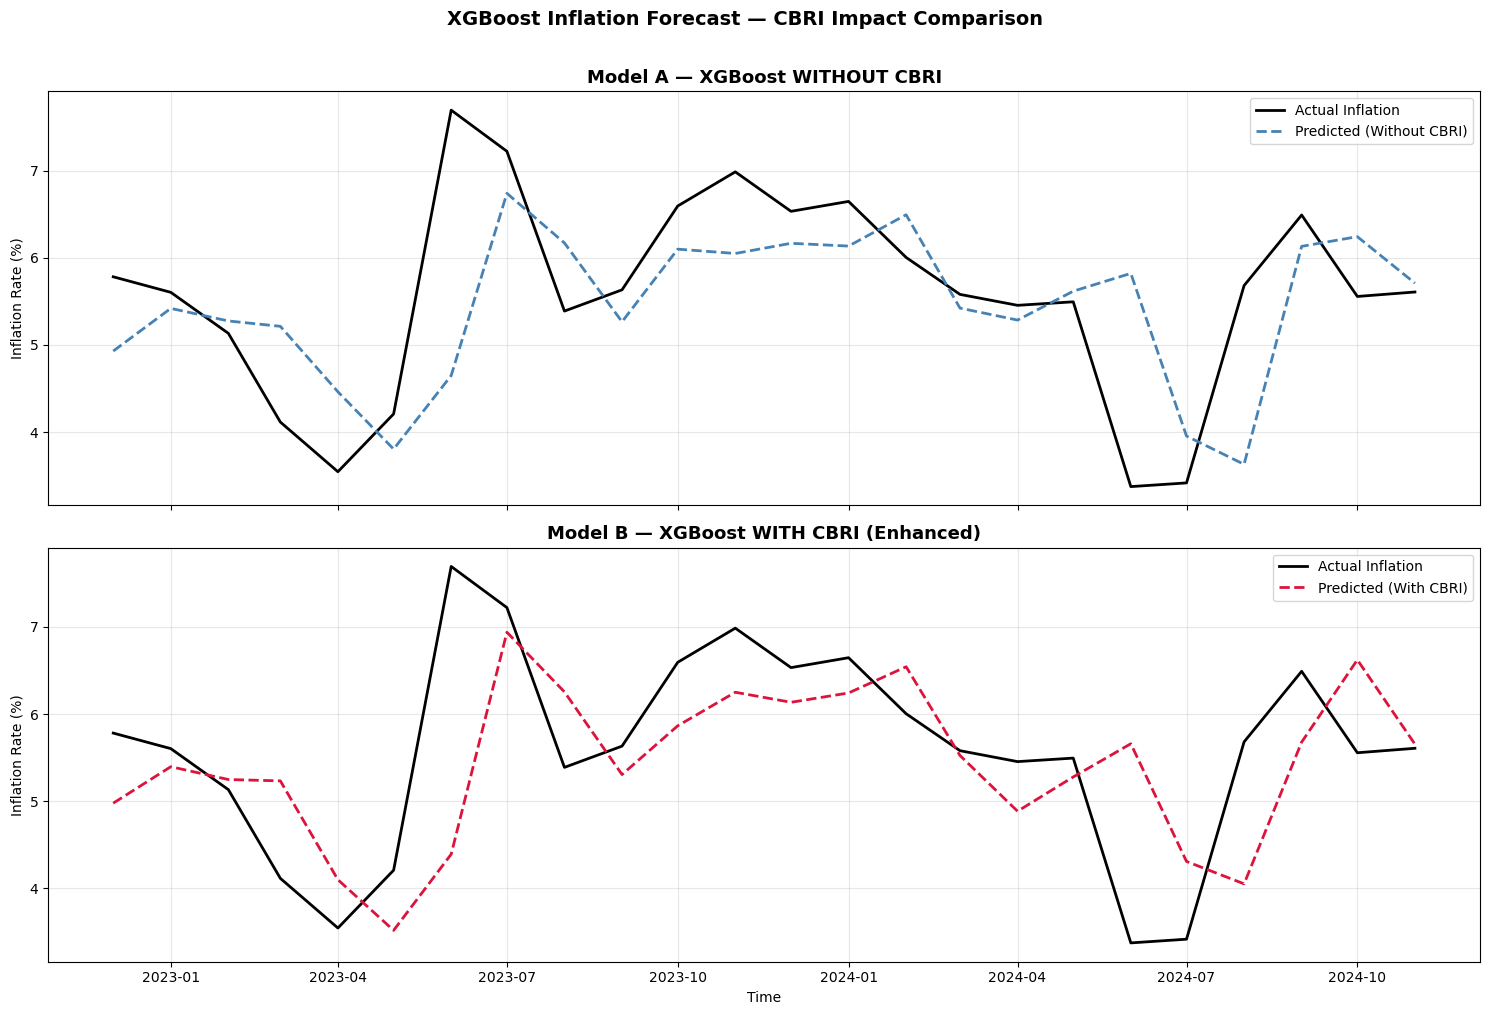

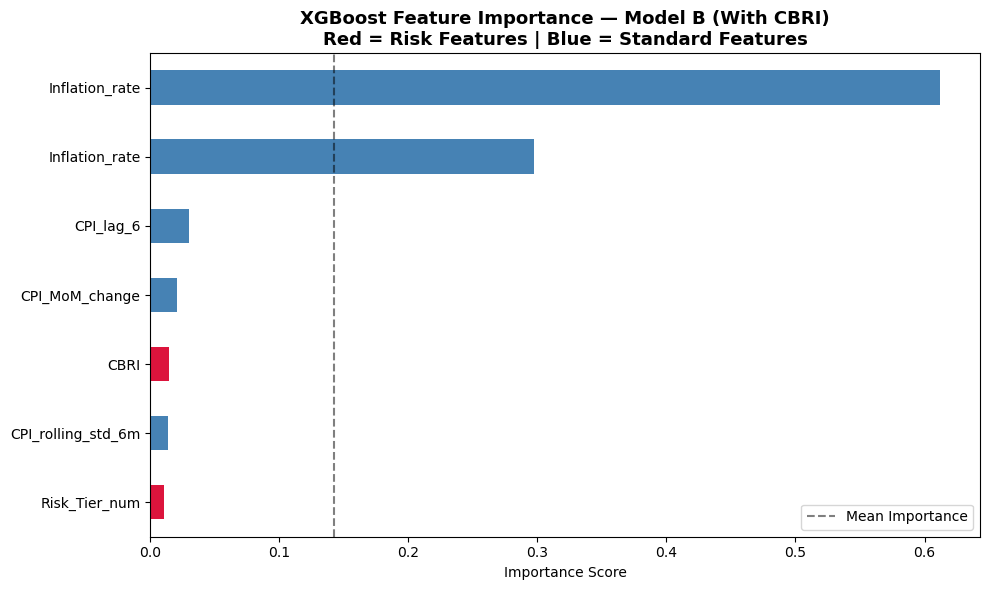


Feature Importances (Model B):
Inflation_rate        0.6123
Inflation_rate        0.2975
CPI_lag_6             0.0300
CPI_MoM_change        0.0207
CBRI                  0.0150
CPI_rolling_std_6m    0.0138
Risk_Tier_num         0.0107
dtype: float32

→ CBRI ranks #5 out of 7 features


In [39]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Step 1: Build forecast dataset
forecast_df = final_data.groupby(final_data.index).agg({
    feat: 'mean' for feat in SELECTED_FEATURES
}).dropna()

# Flatten MultiIndex columns if present
if isinstance(forecast_df.columns, pd.MultiIndex):
    forecast_df.columns = ['_'.join(map(str, c)).strip() 
                           for c in forecast_df.columns]
    SELECTED_FEATURES = list(forecast_df.columns)

# Attach CBRI
forecast_df['CBRI'] = cbri_df['CBRI'].reindex(forecast_df.index)

# Attach Risk Tier as numeric
tier_numeric = {'Normal': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
forecast_df['Risk_Tier_num'] = cbri_df['Risk_Tier'].map(
    tier_numeric).reindex(forecast_df.index)

# Target: next month inflation
forecast_df['Inflation_rate'] = ts_ms.reindex(forecast_df.index)
forecast_df['target'] = forecast_df['Inflation_rate'].shift(-1)

# Drop rows with NaN
forecast_df = forecast_df.dropna(
    subset=['target', 'CBRI', 'Inflation_rate'])

# ── FIX: Squeeze any column that is still a DataFrame into a Series
for col in list(forecast_df.columns):
    while isinstance(forecast_df[col], pd.DataFrame):
        forecast_df[col] = forecast_df[col].iloc[:, 0]
    forecast_df[col] = pd.to_numeric(
        forecast_df[col], errors='coerce')

forecast_df = forecast_df.dropna()

print("Forecast dataset shape:", forecast_df.shape)
print("Dtypes:\n", forecast_df.dtypes)

# ── Step 2: Define feature sets
BASE_FEATURES = SELECTED_FEATURES + ['Inflation_rate']
CBRI_FEATURES = SELECTED_FEATURES + ['Inflation_rate', 'CBRI', 'Risk_Tier_num']

# ── Step 3: Train/test split (80/20 chronological)
split_idx = int(len(forecast_df) * 0.8)
y_test_index = forecast_df.index[split_idx:]

# ── CRITICAL FIX: Extract pure numpy float64 arrays — NO pandas passed to XGBoost
X_base_train = forecast_df[BASE_FEATURES].iloc[:split_idx].to_numpy(dtype=np.float64)
X_base_test  = forecast_df[BASE_FEATURES].iloc[split_idx:].to_numpy(dtype=np.float64)

X_cbri_train = forecast_df[CBRI_FEATURES].iloc[:split_idx].to_numpy(dtype=np.float64)
X_cbri_test  = forecast_df[CBRI_FEATURES].iloc[split_idx:].to_numpy(dtype=np.float64)

y_train = forecast_df['target'].iloc[:split_idx].to_numpy(dtype=np.float64)
y_test  = forecast_df['target'].iloc[split_idx:].to_numpy(dtype=np.float64)

print(f"\nTrain size : {len(y_train)} months")
print(f"Test size  : {len(y_test)} months")
print(f"X_base_train dtype : {X_base_train.dtype}, shape: {X_base_train.shape}")
print(f"X_cbri_train dtype : {X_cbri_train.dtype}, shape: {X_cbri_train.shape}")

# ── Step 4: Train Model A — WITHOUT CBRI (baseline)
xgb_base = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_base.fit(X_base_train, y_train)
y_pred_base = xgb_base.predict(X_base_test)

mae_base  = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mape_base = np.mean(
    np.abs((y_test - y_pred_base) /
           np.where(y_test == 0, np.nan, y_test))
) * 100

print("\n" + "="*50)
print("MODEL A — XGBoost WITHOUT CBRI (Baseline)")
print("="*50)
print(f"  MAE  : {mae_base:.4f}")
print(f"  RMSE : {rmse_base:.4f}")
print(f"  MAPE : {mape_base:.2f}%")

# ── Step 5: Train Model B — WITH CBRI
xgb_cbri = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_cbri.fit(X_cbri_train, y_train)
y_pred_cbri = xgb_cbri.predict(X_cbri_test)

mae_cbri  = mean_absolute_error(y_test, y_pred_cbri)
rmse_cbri = np.sqrt(mean_squared_error(y_test, y_pred_cbri))
mape_cbri = np.mean(
    np.abs((y_test - y_pred_cbri) /
           np.where(y_test == 0, np.nan, y_test))
) * 100

print("\n" + "="*50)
print("MODEL B — XGBoost WITH CBRI (Enhanced)")
print("="*50)
print(f"  MAE  : {mae_cbri:.4f}")
print(f"  RMSE : {rmse_cbri:.4f}")
print(f"  MAPE : {mape_cbri:.2f}%")

# ── Step 6: Improvement calculation
mae_improvement  = round((mae_base  - mae_cbri)  / mae_base  * 100, 2)
rmse_improvement = round((rmse_base - rmse_cbri) / rmse_base * 100, 2)
mape_improvement = round((mape_base - mape_cbri) / mape_base * 100, 2)

print("\n" + "="*50)
print("CBRI IMPACT ON FORECAST ACCURACY")
print("="*50)
print(f"  MAE  improvement  : {mae_improvement:+.2f}%")
print(f"  RMSE improvement  : {rmse_improvement:+.2f}%")
print(f"  MAPE improvement  : {mape_improvement:+.2f}%")

if mae_improvement > 0:
    print("\n  ✅ CBRI IMPROVES forecast accuracy")
    print("     → Anomaly detection signals carry genuine")
    print("       predictive value for inflation forecasting")
else:
    print("\n  ⚠ CBRI did not improve accuracy on this split")
    print("    → Consider tuning contamination rate in")
    print("      Isolation Forest (Section 14)")

# ── Step 7: Actual vs Predicted — both models
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

axes[0].plot(y_test_index, y_test,
             label='Actual Inflation',
             linewidth=2, color='black')
axes[0].plot(y_test_index, y_pred_base,
             label='Predicted (Without CBRI)',
             linestyle='--', linewidth=2, color='steelblue')
axes[0].set_title("Model A — XGBoost WITHOUT CBRI",
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel("Inflation Rate (%)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(y_test_index, y_test,
             label='Actual Inflation',
             linewidth=2, color='black')
axes[1].plot(y_test_index, y_pred_cbri,
             label='Predicted (With CBRI)',
             linestyle='--', linewidth=2, color='crimson')
axes[1].set_title("Model B — XGBoost WITH CBRI (Enhanced)",
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel("Inflation Rate (%)")
axes[1].set_xlabel("Time")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    "XGBoost Inflation Forecast — CBRI Impact Comparison",
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# ── Step 8: Feature importance — Model B
fi = pd.Series(
    xgb_cbri.feature_importances_,
    index=CBRI_FEATURES
).sort_values(ascending=True)

colors = ['crimson' if 'CBRI' in f or 'Risk' in f
          else 'steelblue' for f in fi.index]

plt.figure(figsize=(10, 6))
fi.plot(kind='barh', color=colors)
plt.title("XGBoost Feature Importance — Model B (With CBRI)\n"
          "Red = Risk Features | Blue = Standard Features",
          fontsize=13, fontweight='bold')
plt.xlabel("Importance Score")
plt.axvline(fi.mean(), color='black',
            linestyle='--', alpha=0.5, label='Mean Importance')
plt.legend()
plt.tight_layout()
plt.show()

print("\nFeature Importances (Model B):")
print(fi.sort_values(ascending=False).round(4))

cbri_rank = list(fi.sort_values(ascending=False).index).index('CBRI') + 1
print(f"\n→ CBRI ranks #{cbri_rank} out of {len(CBRI_FEATURES)} features")

## SECTION 20 | FINAL MODEL COMPARISON TABLE

TABLE 1 — FINAL MODEL COMPARISON (Research Paper)
                    Model                          Type    MAE   RMSE  MAPE(%)
             ARIMA(1,1,1)                   Statistical 1.0003 1.2072    19.05
  SARIMA(1,1,1)(1,1,1,12)                   Statistical 0.9796 1.2293    18.32
       XGBoost — Baseline              Machine Learning 0.7378 1.0443    14.37
XGBoost + CBRI (Proposed) Machine Learning + Risk Index 0.7771 1.0630    15.04

Best MAE  : XGBoost — Baseline
Best RMSE : XGBoost — Baseline
Best MAPE : XGBoost — Baseline


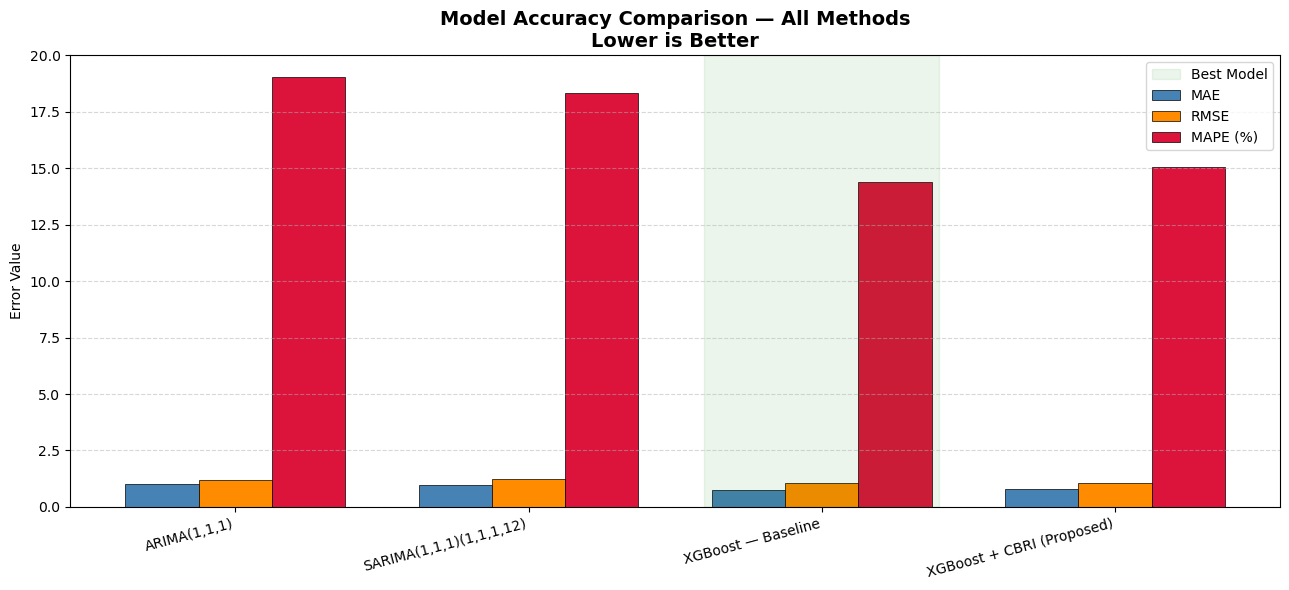


TABLE 2 — ANOMALY DETECTION SUMMARY (Research Paper)
          Method                 Type  Anomalies_Detected      Unique_Contribution
         Z-Score          Statistical                   4 Level deviation baseline
 ARIMA Residuals          Time Series                   5      AR structure shocks
SARIMA Residuals Seasonal Time Series                   6     Seasonal + AR shocks
GARCH Volatility     Volatility Model                   3    Volatility clustering
Isolation Forest     Machine Learning                  10    Multivariate patterns

PROJECT COMPLETION SUMMARY

  Phase 1  ✅  Data Foundation       (Sections 1–4)
  Phase 1b ✅  Feature Selection     (Sections 5–8)
               └─ Variance Threshold
               └─ Correlation Filter
               └─ PCA Variance Analysis
               └─ Final Feature Set locked

  Phase 2  ✅  Anomaly Detection     (Sections 9–15)
               └─ Method 1: Z-Score
               └─ Method 2: ARIMA Residuals
               └─ Method 3:

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── ARIMA accuracy (recompute cleanly)
train_n    = int(len(ts_ms) * 0.8)
tr_a, te_a = ts_ms.iloc[:train_n], ts_ms.iloc[train_n:]

from statsmodels.tsa.arima.model import ARIMA
arima_fc_t = ARIMA(tr_a, order=(1,1,1)).fit().forecast(
    steps=len(te_a))
mae_a  = mean_absolute_error(te_a, arima_fc_t)
rmse_a = np.sqrt(mean_squared_error(te_a, arima_fc_t))
mape_a = np.mean(np.abs((te_a - arima_fc_t)/te_a)) * 100

# ── SARIMA accuracy
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_fc_t = SARIMAX(
    tr_a, order=(1,1,1),
    seasonal_order=(1,1,1,12)
).fit(disp=False).forecast(steps=len(te_a))
mae_s  = mean_absolute_error(te_a, sarima_fc_t)
rmse_s = np.sqrt(mean_squared_error(te_a, sarima_fc_t))
mape_s = np.mean(np.abs((te_a - sarima_fc_t)/te_a)) * 100

# ── Build comparison table
results = pd.DataFrame({
    'Model': [
        'ARIMA(1,1,1)',
        'SARIMA(1,1,1)(1,1,1,12)',
        'XGBoost — Baseline',
        'XGBoost + CBRI (Proposed)'
    ],
    'Type': [
        'Statistical',
        'Statistical',
        'Machine Learning',
        'Machine Learning + Risk Index'
    ],
    'MAE': [
        round(mae_a, 4),
        round(mae_s, 4),
        round(mae_base, 4),
        round(mae_cbri, 4)
    ],
    'RMSE': [
        round(rmse_a, 4),
        round(rmse_s, 4),
        round(rmse_base, 4),
        round(rmse_cbri, 4)
    ],
    'MAPE(%)': [
        round(mape_a, 2),
        round(mape_s, 2),
        round(mape_base, 2),
        round(mape_cbri, 2)
    ]
})

# Mark best model per metric
best_mae  = results['MAE'].idxmin()
best_rmse = results['RMSE'].idxmin()
best_mape = results['MAPE(%)'].idxmin()

print("="*72)
print("TABLE 1 — FINAL MODEL COMPARISON (Research Paper)")
print("="*72)
print(results.to_string(index=False))
print("="*72)
print(f"\nBest MAE  : {results.loc[best_mae,  'Model']}")
print(f"Best RMSE : {results.loc[best_rmse, 'Model']}")
print(f"Best MAPE : {results.loc[best_mape, 'Model']}")

# ── Grouped bar chart
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(results)); w = 0.25

bars1 = ax.bar(x - w,   results['MAE'],
               w, label='MAE',
               color='steelblue',   edgecolor='black',
               linewidth=0.5)
bars2 = ax.bar(x,       results['RMSE'],
               w, label='RMSE',
               color='darkorange',  edgecolor='black',
               linewidth=0.5)
bars3 = ax.bar(x + w,   results['MAPE(%)'],
               w, label='MAPE (%)',
               color='crimson',     edgecolor='black',
               linewidth=0.5)

# Highlight best model
ax.axvspan(best_mae - 0.4, best_mae + 0.4,
           alpha=0.08, color='green',
           label='Best Model')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=15, ha='right')
ax.set_title("Model Accuracy Comparison — All Methods\n"
             "Lower is Better",
             fontsize=14, fontweight='bold')
ax.set_ylabel("Error Value")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ── Anomaly detection summary table
print("\n" + "="*65)
print("TABLE 2 — ANOMALY DETECTION SUMMARY (Research Paper)")
print("="*65)

anomaly_summary = pd.DataFrame({
    'Method': [
        'Z-Score',
        'ARIMA Residuals',
        'SARIMA Residuals',
        'GARCH Volatility',
        'Isolation Forest'
    ],
    'Type': [
        'Statistical',
        'Time Series',
        'Seasonal Time Series',
        'Volatility Model',
        'Machine Learning'
    ],
    'Anomalies_Detected': [
        len(zscore_anomaly_dates),
        len(arima_anomaly_dates),
        len(sarima_anomaly_dates),
        len(garch_anomaly_dates),
        len(iso_anomaly_dates)
    ],
    'Unique_Contribution': [
        'Level deviation baseline',
        'AR structure shocks',
        'Seasonal + AR shocks',
        'Volatility clustering',
        'Multivariate patterns'
    ]
})

